# Assignment 2


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Question 1 - NumPy Array Operations

In [3]:
A = np.array([
    [12, 5, 8, 20],
    [7, 15, 3, 11],
    [25, 9, 18, 6],
    [10, 14, 2, 16]
])

print(A)

[[12  5  8 20]
 [ 7 15  3 11]
 [25  9 18  6]
 [10 14  2 16]]


In [4]:
row_mean = A.mean(axis=1)

print("Row means:")
print(row_mean)

Row means:
[11.25  9.   14.5  10.5 ]


In [5]:
binary_matrix = (A > row_mean[:, np.newaxis]).astype(int)

print("Binary Matrix:")
print(binary_matrix)

Binary Matrix:
[[1 0 0 1]
 [0 1 0 1]
 [1 0 1 0]
 [0 1 0 1]]


In [6]:
count_above_mean = binary_matrix.sum(axis=1)

print("Count of elements above row mean:")
print(count_above_mean)

print("Row with maximum elements above its mean:", np.argmax(count_above_mean))

Count of elements above row mean:
[2 2 2 2]
Row with maximum elements above its mean: 0


Question 2 - Outlier Detection using NumPy

In [7]:
X = np.array([
    [10, 100, 5],
    [12, 110, 6],
    [11, 105, 7],
    [13, 500, 6],
    [14, 108, 8],
    [15, 115, 9]
])

print("Original Data:")
print(X)

Original Data:
[[ 10 100   5]
 [ 12 110   6]
 [ 11 105   7]
 [ 13 500   6]
 [ 14 108   8]
 [ 15 115   9]]


In [8]:
mean = X.mean(axis=0)
std = X.std(axis=0)

print("Column Mean:")
print(mean)

print("\nColumn Standard Deviation:")
print(std)

Column Mean:
[ 12.5        173.           6.83333333]

Column Standard Deviation:
[  1.70782513 146.31017281   1.34370962]


In [9]:
outlier_mask = np.abs(X - mean) > 2 * std

print("Outlier Mask:")
print(outlier_mask)

Outlier Mask:
[[False False False]
 [False False False]
 [False False False]
 [False  True False]
 [False False False]
 [False False False]]


In [10]:
median = np.median(X, axis=0)

X_clean = X.copy()
X_clean[outlier_mask] = np.broadcast_to(median, X.shape)[outlier_mask]

print("Cleaned Data:")
print(X_clean)

Cleaned Data:
[[ 10 100   5]
 [ 12 110   6]
 [ 11 105   7]
 [ 13 109   6]
 [ 14 108   8]
 [ 15 115   9]]


Question 3 - Student Data Analysis

In [11]:
import pandas as pd

df = pd.DataFrame({
    'Student': ['A','B','C','D','E','F','G','H'],
    'Department': ['CSE','CSE','ECE','ECE','CSE','ECE','CSE','ECE'],
    'Gender': ['F','M','F','M','F','M','F','M'],
    'Marks': [75,92,65,78,88,95,70,72],
    'Attendance': [92,81,96,72,85,90,98,75]
})

df

,Student,Department,Gender,Marks,Attendance
0,A,CSE,F,75,92
1,B,CSE,M,92,81
2,C,ECE,F,65,96
3,D,ECE,M,78,72
4,E,CSE,F,88,85
5,F,ECE,M,95,90
6,G,CSE,F,70,98
7,H,ECE,M,72,75


In [12]:
dept_avg = df.groupby('Department')['Marks'].mean()

print("Average Marks by Department:")
print(dept_avg)

Average Marks by Department:
Department
CSE    81.25
ECE    77.50
Name: Marks, dtype: float64


In [13]:
dept_gender_avg = df.groupby(['Department', 'Gender'])['Marks'].mean()

print("Average Marks by Department and Gender:")
print(dept_gender_avg)

Average Marks by Department and Gender:
Department  Gender
CSE         F         77.666667
            M         92.000000
ECE         F         65.000000
            M         81.666667
Name: Marks, dtype: float64


In [14]:
top_student = df.loc[df['Marks'].idxmax()]

print("Student with highest marks:")
print(top_student)

Student with highest marks:
Student         F
Department    ECE
Gender          M
Marks          95
Attendance     90
Name: 5, dtype: object


In [15]:
df['Department_Average'] = df.groupby('Department')['Marks'].transform('mean')

above_average = df[df['Marks'] > df['Department_Average']]

print("Students scoring above their department average:")
print(above_average[['Student', 'Department', 'Marks']])

Students scoring above their department average:
  Student Department  Marks
1       B        CSE     92
3       D        ECE     78
4       E        CSE     88
5       F        ECE     95


In [16]:
dept_attendance = df.groupby('Department')['Attendance'].mean()

print("Average Attendance by Department:")
print(dept_attendance)

print("\nDepartment with highest average attendance:")
print(dept_attendance.idxmax())

Average Attendance by Department:
Department
CSE    89.00
ECE    83.25
Name: Attendance, dtype: float64

Department with highest average attendance:
CSE


Question 4 - Handling Duplicate Records

In [17]:
df = pd.DataFrame({
    'ID': [101, 102, 103, 101, 104, 102, 105],
    'Name': ['A', 'B', 'C', 'A', 'D', 'B', 'E'],
    'Age': [20, 21, 22, 23, 24, 22, 25],
    'Score': [80, 75, 90, 85, 78, 85, 92]
})

print("Original DataFrame:")
print(df)

Original DataFrame:
    ID Name  Age  Score
0  101    A   20     80
1  102    B   21     75
2  103    C   22     90
3  101    A   23     85
4  104    D   24     78
5  102    B   22     85
6  105    E   25     92


In [18]:
duplicates = df[df.duplicated('ID', keep=False)]

print("Duplicate ID records:")
print(duplicates)

Duplicate ID records:
    ID Name  Age  Score
0  101    A   20     80
1  102    B   21     75
3  101    A   23     85
5  102    B   22     85


In [19]:
df_clean = df.loc[df.groupby('ID')['Score'].idxmax()].reset_index(drop=True)

print("Cleaned DataFrame:")
print(df_clean)

Cleaned DataFrame:
    ID Name  Age  Score
0  101    A   23     85
1  102    B   22     85
2  103    C   22     90
3  104    D   24     78
4  105    E   25     92


In [20]:
print("Number of unique IDs:", df_clean['ID'].nunique())
print("Number of rows after cleaning:", len(df_clean))

Number of unique IDs: 5
Number of rows after cleaning: 5


In [21]:
duplicate_count = df.duplicated('ID').sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 2


Question 5 - Date Handling and Rolling Average

In [22]:
df = pd.DataFrame({
    'Date': [
        '2026-01-01',
        '2026-01-02',
        '2026-01-04',
        '2026-01-05',
        '2026-01-08',
        '2026-01-09'
    ],
    'Sales': [100, 120, 150, 130, 180, 200]
})

print(df)

         Date  Sales
0  2026-01-01    100
1  2026-01-02    120
2  2026-01-04    150
3  2026-01-05    130
4  2026-01-08    180
5  2026-01-09    200


In [23]:
df['Date'] = pd.to_datetime(df['Date'])

print(df.dtypes)

Date     datetime64[ns]
Sales             int64
dtype: object


In [24]:
full_dates = pd.date_range(
    start=df['Date'].min(),
    end=df['Date'].max(),
    freq='D'
)

missing_dates = full_dates.difference(df['Date'])

print("Missing Dates:")
print(missing_dates)

Missing Dates:
DatetimeIndex(['2026-01-03', '2026-01-06', '2026-01-07'], dtype='datetime64[ns]', freq=None)


In [25]:
df = df.set_index('Date').reindex(full_dates)

df.index.name = 'Date'

print(df)

            Sales
Date             
2026-01-01  100.0
2026-01-02  120.0
2026-01-03    NaN
2026-01-04  150.0
2026-01-05  130.0
2026-01-06    NaN
2026-01-07    NaN
2026-01-08  180.0
2026-01-09  200.0


In [26]:
print("Missing Sales:")
print(df[df['Sales'].isna()])

Missing Sales:
            Sales
Date             
2026-01-03    NaN
2026-01-06    NaN
2026-01-07    NaN


In [27]:
df['Rolling_Average'] = df['Sales'].rolling(window=3).mean()

print(df)

            Sales  Rolling_Average
Date                              
2026-01-01  100.0              NaN
2026-01-02  120.0              NaN
2026-01-03    NaN              NaN
2026-01-04  150.0              NaN
2026-01-05  130.0              NaN
2026-01-06    NaN              NaN
2026-01-07    NaN              NaN
2026-01-08  180.0              NaN
2026-01-09  200.0              NaN


In [28]:
max_date = df['Rolling_Average'].idxmax()
max_value = df['Rolling_Average'].max()

print("Date with maximum rolling average:", max_date)
print("Maximum rolling average:", max_value)

Date with maximum rolling average: NaT
Maximum rolling average: nan


/tmp/ipykernel_1530/840150848.py:1: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  max_date = df['Rolling_Average'].idxmax()


Question 6 - Pairwise Euclidean Distance using Broadcasting

In [29]:
np.random.seed(42)

points = np.random.rand(5, 2)

print("Points:")
print(points)

Points:
[[0.37454012 0.95071431]
 [0.73199394 0.59865848]
 [0.15601864 0.15599452]
 [0.05808361 0.86617615]
 [0.60111501 0.70807258]]


In [30]:
diff = points[:, np.newaxis, :] - points[np.newaxis, :, :]

distance_matrix = np.sqrt(np.sum(diff ** 2, axis=2))

print("Pairwise Euclidean Distance Matrix:")
print(distance_matrix)

Pairwise Euclidean Distance Matrix:
[[0.         0.5017136  0.82421549 0.32755369 0.33198071]
 [0.5017136  0.         0.72642889 0.72506609 0.17058938]
 [0.82421549 0.72642889 0.         0.71690251 0.7091551 ]
 [0.32755369 0.72506609 0.71690251 0.         0.56557921]
 [0.33198071 0.17058938 0.7091551  0.56557921 0.        ]]


In [31]:
print("Matrix shape:", distance_matrix.shape)
print("Diagonal:", np.diag(distance_matrix))

Matrix shape: (5, 5)
Diagonal: [0. 0. 0. 0. 0.]


# Question 7A - Car Price Dataset

In [32]:
car = pd.read_csv("CarPrice_Assignment.csv")

print("Shape:", car.shape)
car.head()

Shape: (205, 26)


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [33]:
print("Data Types:")
print(car.dtypes)

print("\nMissing Values:")
print(car.isnull().sum())

print("\nDuplicate Rows:")
print(car.duplicated().sum())

print("\nStatistical Summary:")
print(car.describe())

Data Types:
car_ID                int64
symboling             int64
CarName              object
fueltype             object
aspiration           object
doornumber           object
carbody              object
drivewheel           object
enginelocation       object
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype           object
cylindernumber       object
enginesize            int64
fuelsystem           object
boreratio           float64
stroke              float64
compressionratio    float64
horsepower            int64
peakrpm               int64
citympg               int64
highwaympg            int64
price               float64
dtype: object

Missing Values:
car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength

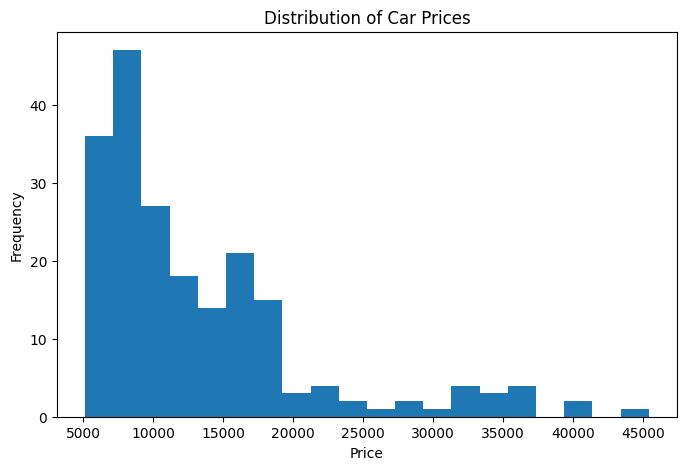

In [34]:
plt.figure(figsize=(8, 5))
plt.hist(car['price'], bins=20)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Car Prices")
plt.show()

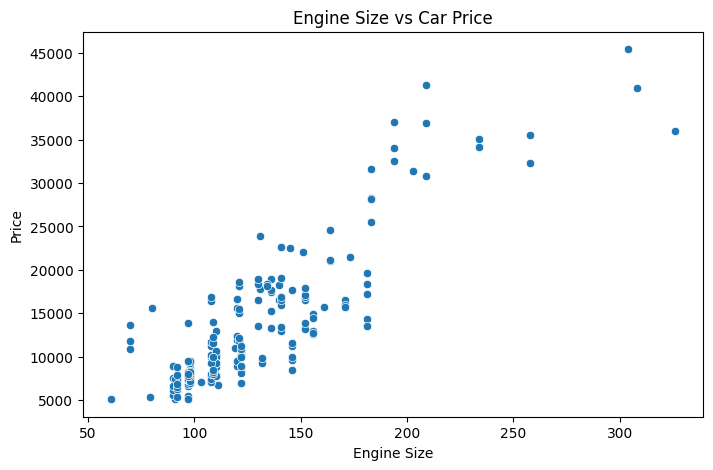

In [35]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=car, x='enginesize', y='price')
plt.xlabel("Engine Size")
plt.ylabel("Price")
plt.title("Engine Size vs Car Price")
plt.show()

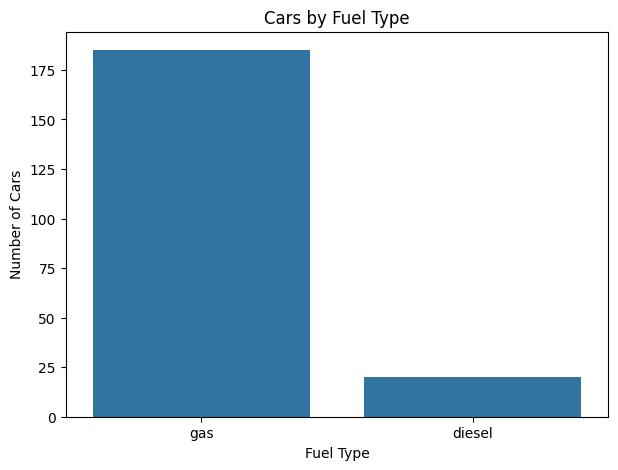

In [36]:
plt.figure(figsize=(7, 5))
sns.countplot(data=car, x='fueltype')
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")
plt.title("Cars by Fuel Type")
plt.show()

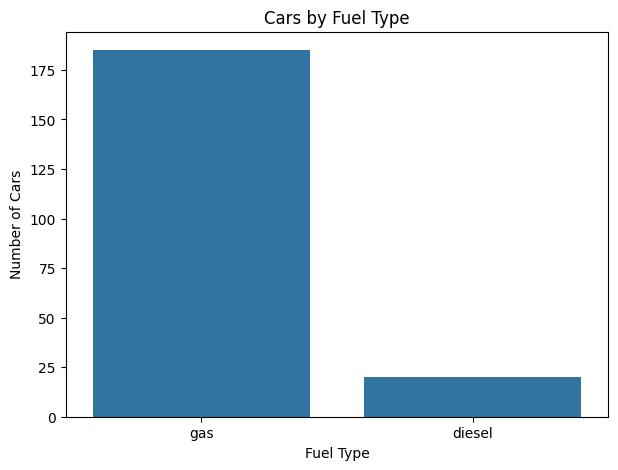

In [37]:
plt.figure(figsize=(7, 5))
sns.countplot(data=car, x='fueltype')
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")
plt.title("Cars by Fuel Type")
plt.show()

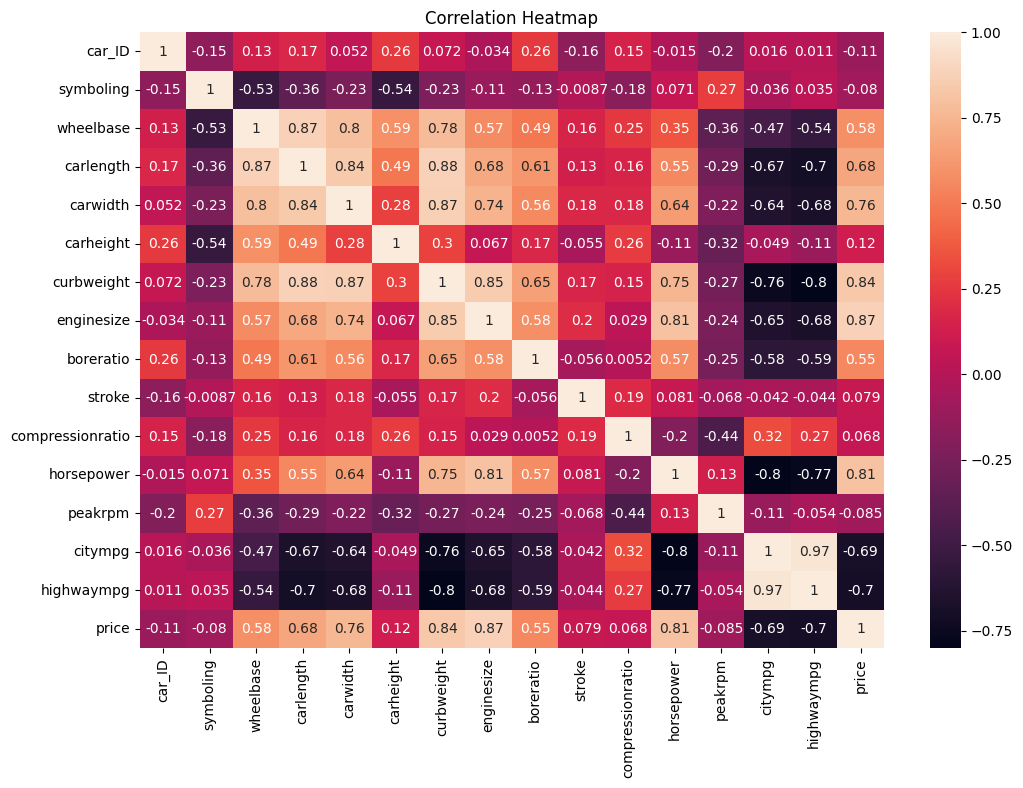

In [38]:
plt.figure(figsize=(12, 8))

corr = car.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")
plt.show()

**Insights:**

- Car prices vary considerably across the dataset.
- Engine size has a noticeable relationship with car price.
- The dataset contains cars using different fuel types.
- The price distribution helps identify the spread and possible extreme values.
- The correlation heatmap shows relationships between numerical variables.

Question 7B - Diabetes Dataset

In [39]:
diabetes = pd.read_csv("diabetes.csv")

print("Shape:", diabetes.shape)
diabetes.head()

Shape: (403, 19)


,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0


In [40]:
print("Data Types:")
print(diabetes.dtypes)

print("\nMissing Values:")
print(diabetes.isnull().sum())

print("\nDuplicate Rows:")
print(diabetes.duplicated().sum())

print("\nStatistical Summary:")
print(diabetes.describe())

Data Types:
id            int64
chol        float64
stab.glu      int64
hdl         float64
ratio       float64
glyhb       float64
location     object
age           int64
gender       object
height      float64
weight      float64
frame        object
bp.1s       float64
bp.1d       float64
bp.2s       float64
bp.2d       float64
waist       float64
hip         float64
time.ppn    float64
dtype: object

Missing Values:
id            0
chol          1
stab.glu      0
hdl           1
ratio         1
glyhb        13
location      0
age           0
gender        0
height        5
weight        1
frame        12
bp.1s         5
bp.1d         5
bp.2s       262
bp.2d       262
waist         2
hip           2
time.ppn      3
dtype: int64

Duplicate Rows:
0

Statistical Summary:
                 id        chol    stab.glu         hdl       ratio  \
count    403.000000  402.000000  403.000000  402.000000  402.000000   
mean   15978.310174  207.845771  106.672457   50.445274    4.521642   
std   

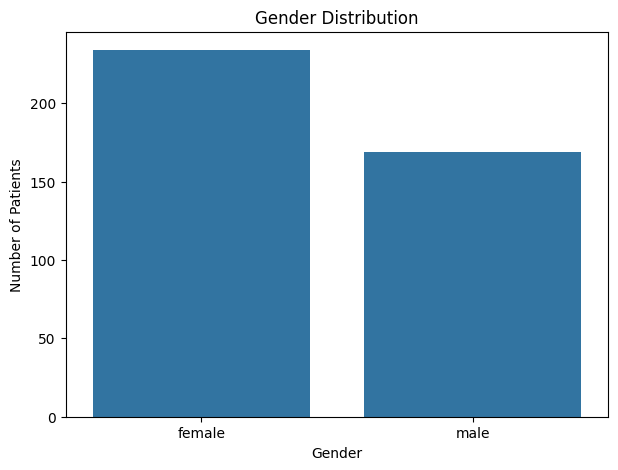

In [41]:
plt.figure(figsize=(7, 5))
sns.countplot(data=diabetes, x='gender')
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.title("Gender Distribution")
plt.show()

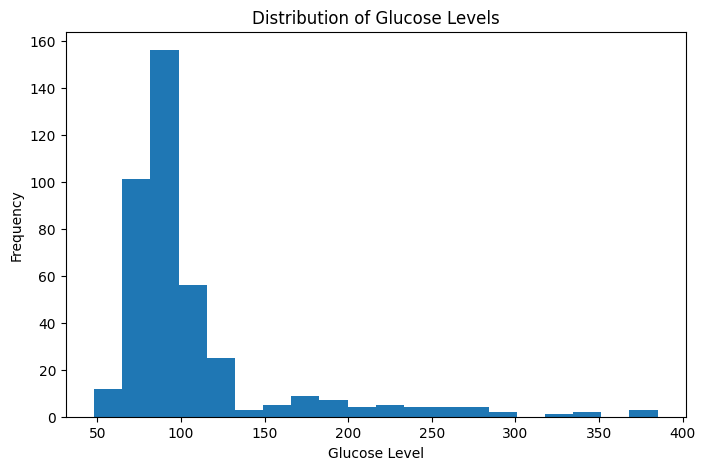

In [42]:
plt.figure(figsize=(8, 5))
plt.hist(diabetes['stab.glu'].dropna(), bins=20)
plt.xlabel("Glucose Level")
plt.ylabel("Frequency")
plt.title("Distribution of Glucose Levels")
plt.show()

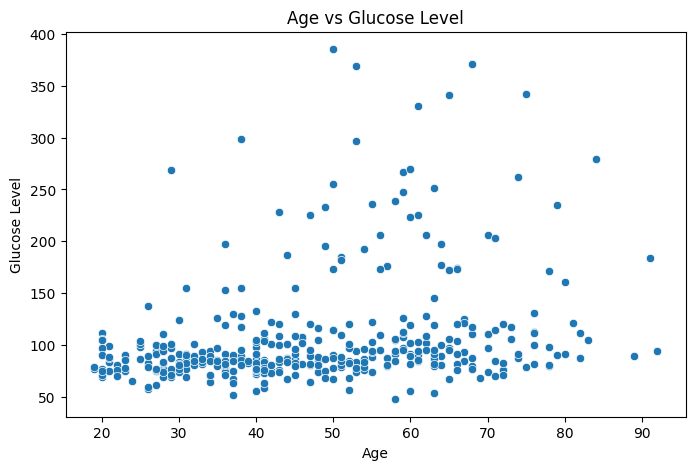

In [43]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=diabetes, x='age', y='stab.glu')
plt.xlabel("Age")
plt.ylabel("Glucose Level")
plt.title("Age vs Glucose Level")
plt.show()

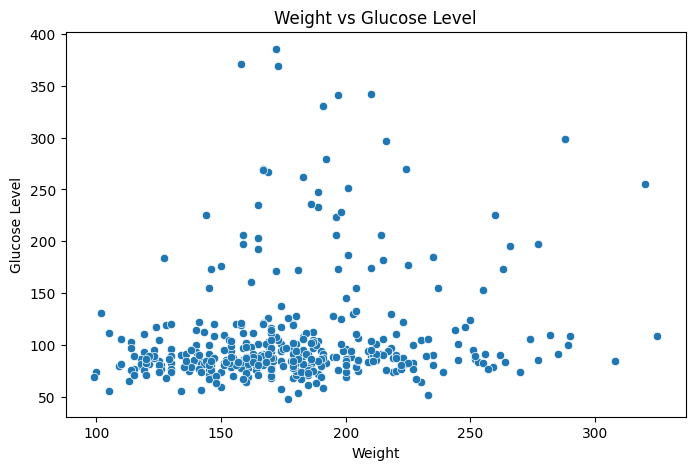

In [44]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=diabetes, x='weight', y='stab.glu')
plt.xlabel("Weight")
plt.ylabel("Glucose Level")
plt.title("Weight vs Glucose Level")
plt.show()

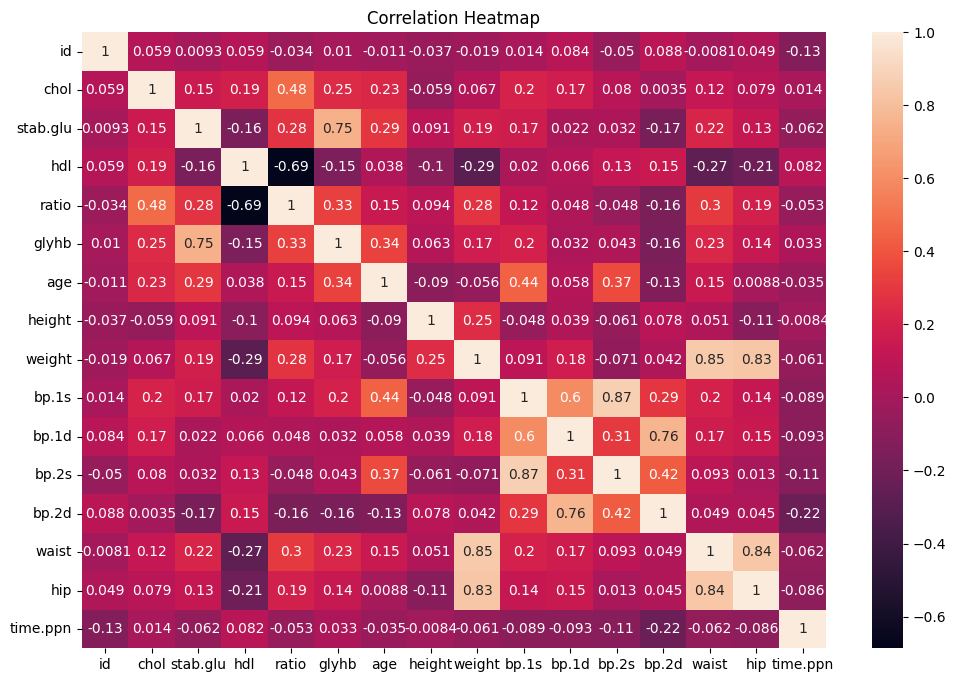

In [45]:
plt.figure(figsize=(12, 8))

corr = diabetes.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")
plt.show()

**Insights:**

- The dataset contains various health-related measurements of patients.
- Glucose levels show variation across different patients.
- Age and weight can be compared with glucose levels to observe possible relationships.
- The dataset contains both numerical and categorical attributes such as gender and location.
- The correlation heatmap helps identify relationships among the numerical health variables.

Question 7C - Housing Dataset

In [46]:
housing = pd.read_csv("housing.csv")

print("Shape:", housing.shape)
housing.head()

Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [47]:
print("Columns:")
print(housing.columns.tolist())

print("\nData Types:")
print(housing.dtypes)

print("\nMissing Values:")
print(housing.isnull().sum())

print("\nDuplicate Rows:")
print(housing.duplicated().sum())

print("\nStatistical Summary:")
print(housing.describe())

Columns:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']

Data Types:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

Missing Values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Duplicate Rows:
0

Statistical Summary:
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     

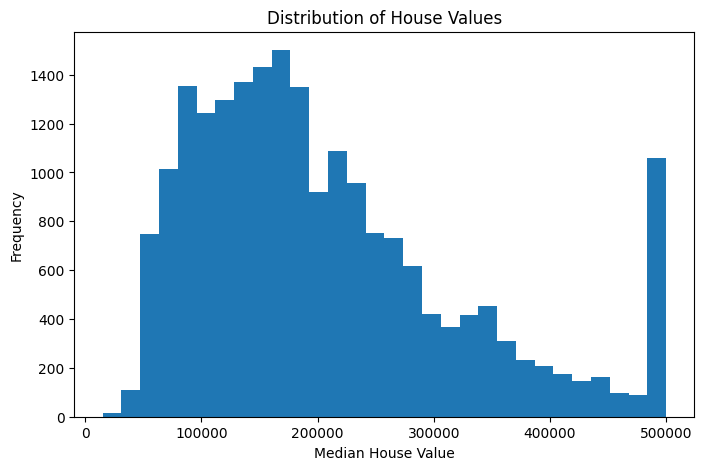

In [48]:
plt.figure(figsize=(8, 5))
plt.hist(housing['median_house_value'], bins=30)
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.title("Distribution of House Values")
plt.show()

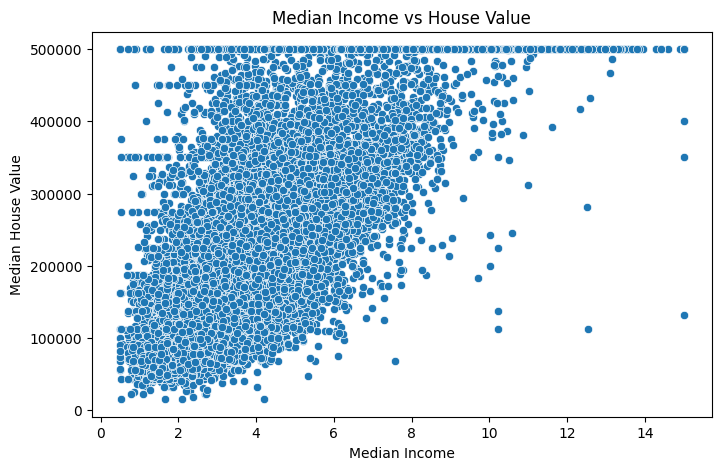

In [49]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=housing, x='median_income', y='median_house_value')
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs House Value")
plt.show()

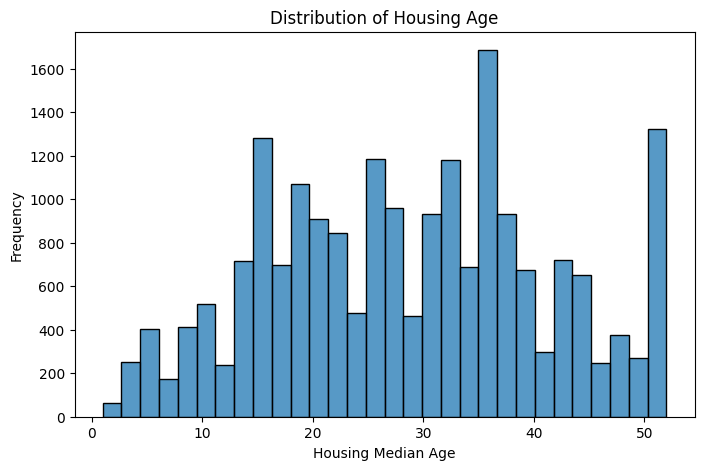

In [50]:
plt.figure(figsize=(8, 5))
sns.histplot(data=housing, x='housing_median_age', bins=30)
plt.xlabel("Housing Median Age")
plt.ylabel("Frequency")
plt.title("Distribution of Housing Age")
plt.show()

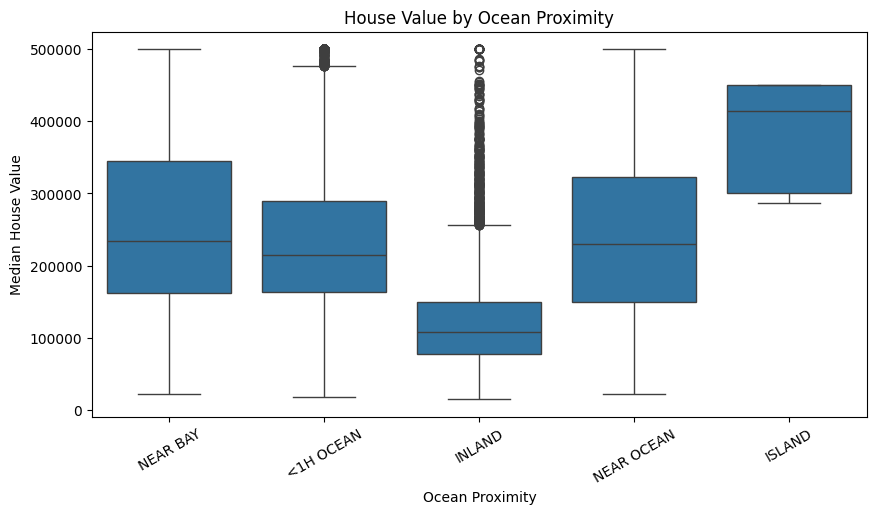

In [51]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=housing, x='ocean_proximity', y='median_house_value')
plt.xlabel("Ocean Proximity")
plt.ylabel("Median House Value")
plt.title("House Value by Ocean Proximity")
plt.xticks(rotation=30)
plt.show()

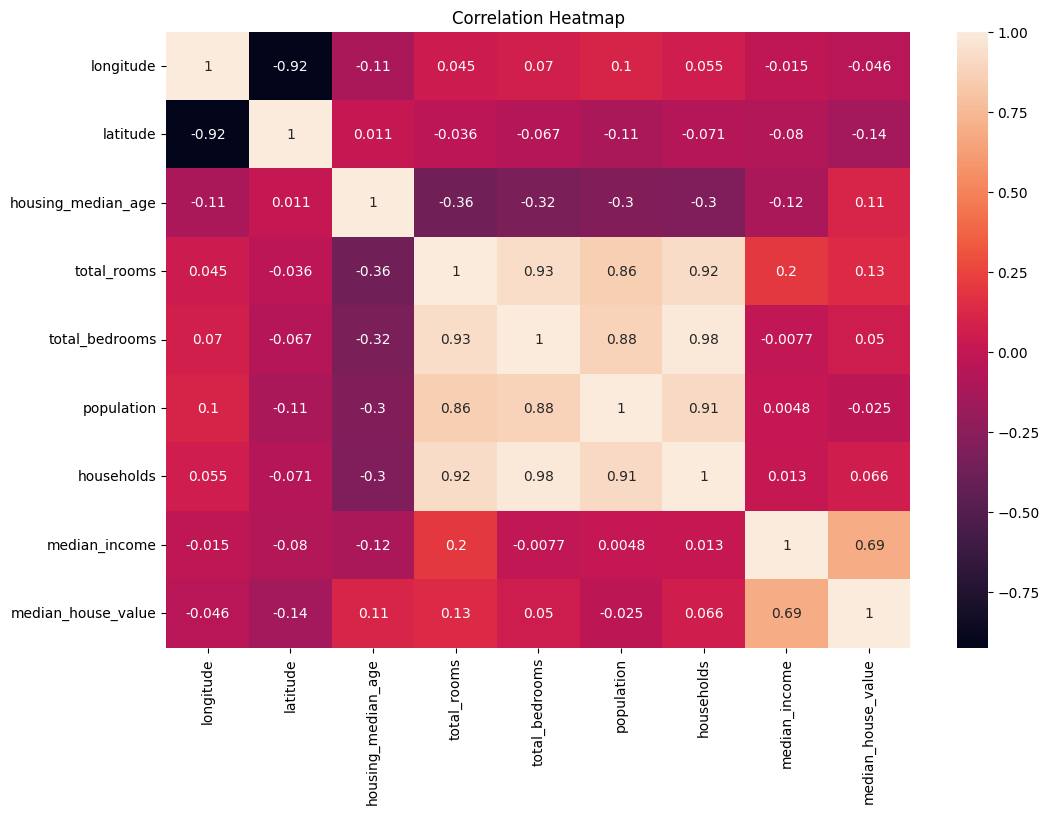

In [52]:
plt.figure(figsize=(12, 8))

corr = housing.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")
plt.show()

**Insights:**

- House values show considerable variation across the dataset.
- Median income has a positive relationship with median house value.
- Housing age varies considerably across different observations.
- House values differ across ocean proximity categories.
- The correlation heatmap shows relationships between the numerical housing features.

Question 7D - Mall Customers Dataset

In [53]:
mall = pd.read_csv("Mall_Customers.csv")

print("Shape:", mall.shape)
mall.head()

Shape: (200, 5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [54]:
print("Columns:")
print(mall.columns.tolist())

print("\nData Types:")
print(mall.dtypes)

print("\nMissing Values:")
print(mall.isnull().sum())

print("\nDuplicate Rows:")
print(mall.duplicated().sum())

print("\nStatistical Summary:")
print(mall.describe())

Columns:
['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Data Types:
CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Missing Values:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate Rows:
0

Statistical Summary:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               5

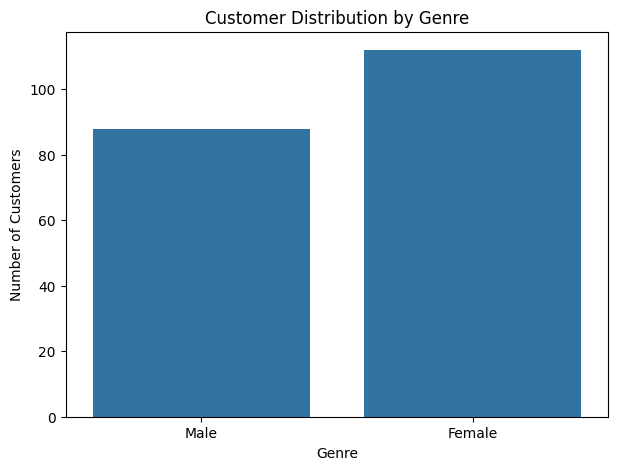

In [55]:
plt.figure(figsize=(7, 5))
sns.countplot(data=mall, x='Genre')
plt.xlabel("Genre")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution by Genre")
plt.show()

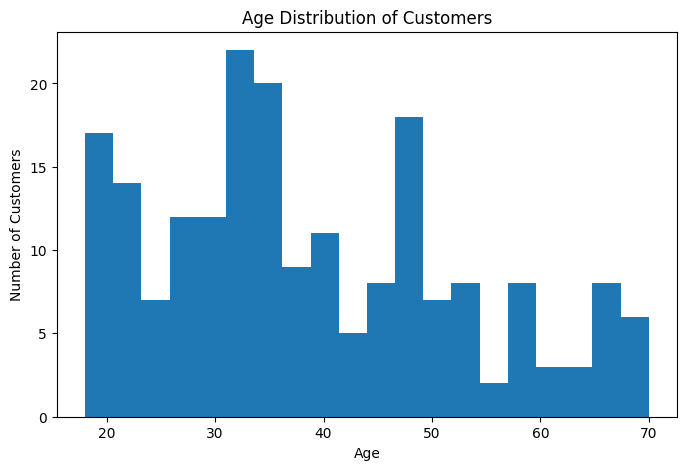

In [56]:
plt.figure(figsize=(8, 5))
plt.hist(mall['Age'], bins=20)
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Age Distribution of Customers")
plt.show()

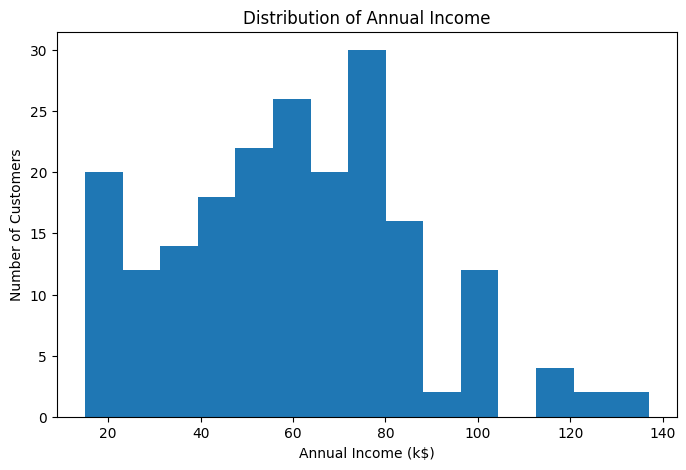

In [57]:
plt.figure(figsize=(8, 5))
plt.hist(mall['Annual Income (k$)'], bins=15)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Annual Income")
plt.show()

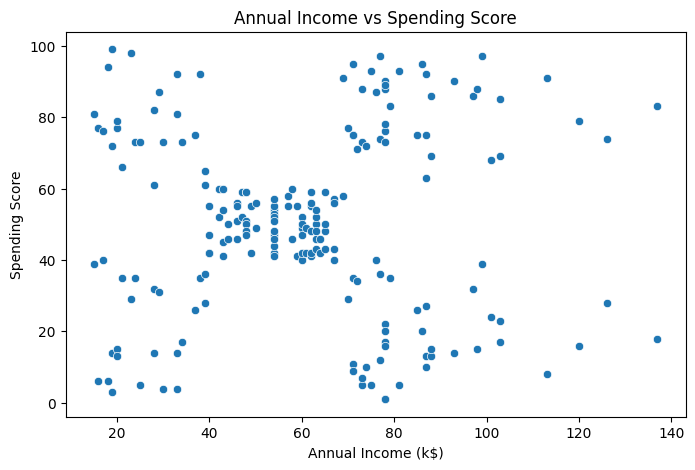

In [58]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=mall,
    x='Annual Income (k$)',
    y='Spending Score (1-100)'
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Annual Income vs Spending Score")
plt.show()

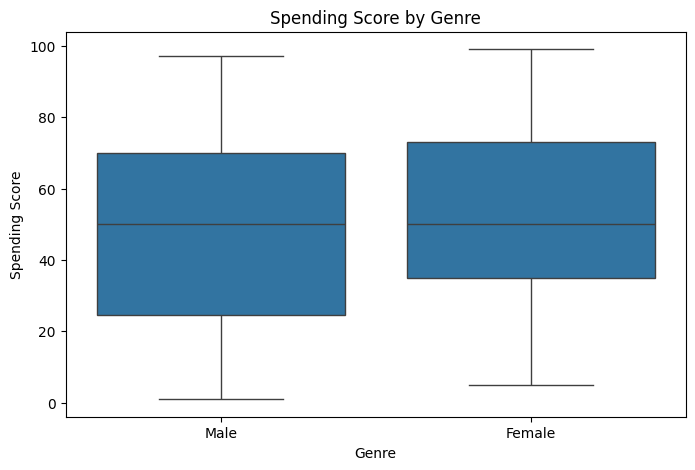

In [59]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=mall, x='Genre', y='Spending Score (1-100)')
plt.xlabel("Genre")
plt.ylabel("Spending Score")
plt.title("Spending Score by Genre")
plt.show()

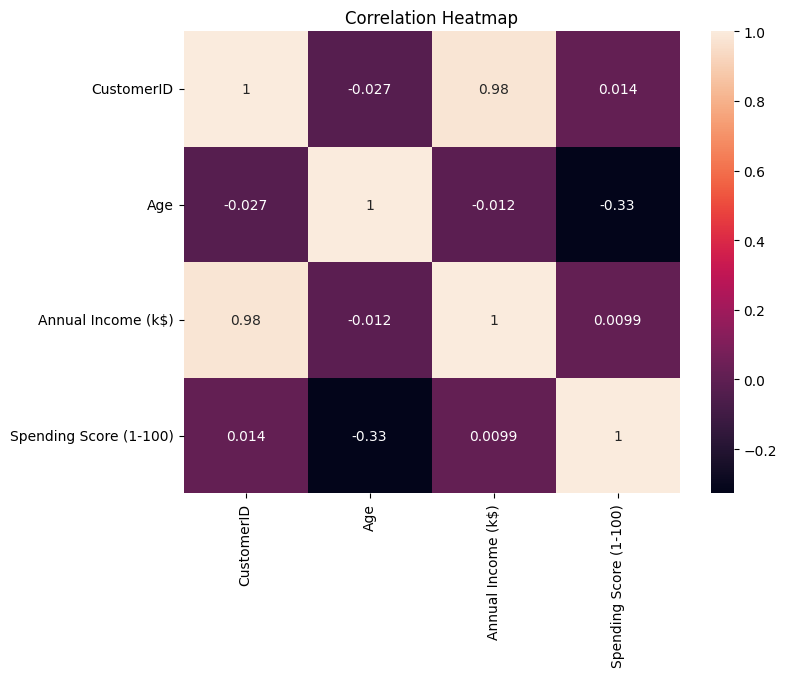

In [60]:
plt.figure(figsize=(8, 6))

corr = mall.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")
plt.show()

**Insights:**

- The dataset contains customers with different ages, income levels and spending scores.
- The customers belong to different genres.
- Annual income varies considerably among customers.
- The relationship between annual income and spending score can be observed using the scatter plot.
- The correlation heatmap shows relationships among the numerical variables.

Question 7E - Netflix Dataset

In [61]:
netflix = pd.read_csv("NetFlix.csv")

print("Shape:", netflix.shape)
netflix.head()

Shape: (7787, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


In [62]:
print("Columns:")
print(netflix.columns.tolist())

print("\nData Types:")
print(netflix.dtypes)

print("\nMissing Values:")
print(netflix.isnull().sum())

print("\nDuplicate Rows:")
print(netflix.duplicated().sum())

print("\nStatistical Summary:")
print(netflix.describe(include='all'))

Columns:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'genres', 'description']

Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration         int64
genres          object
description     object
dtype: object

Missing Values:
show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
genres             0
description        0
dtype: int64

Duplicate Rows:
0

Statistical Summary:
       show_id   type     title                director                cast  \
count     7787   7787      7787                    5398                7069   
unique    7787      2      7787                    4049               

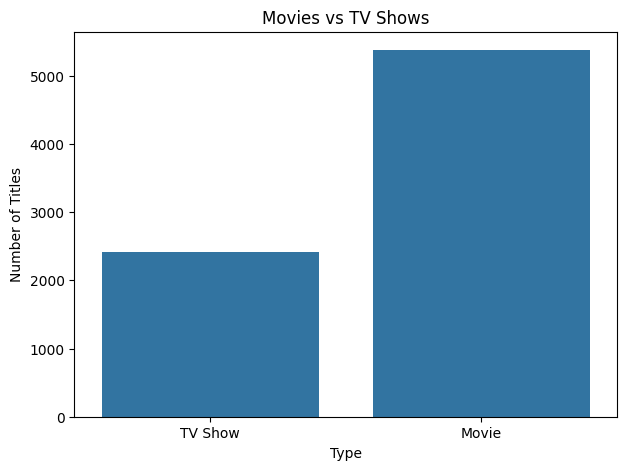

In [63]:
plt.figure(figsize=(7, 5))
sns.countplot(data=netflix, x='type')
plt.xlabel("Type")
plt.ylabel("Number of Titles")
plt.title("Movies vs TV Shows")
plt.show()

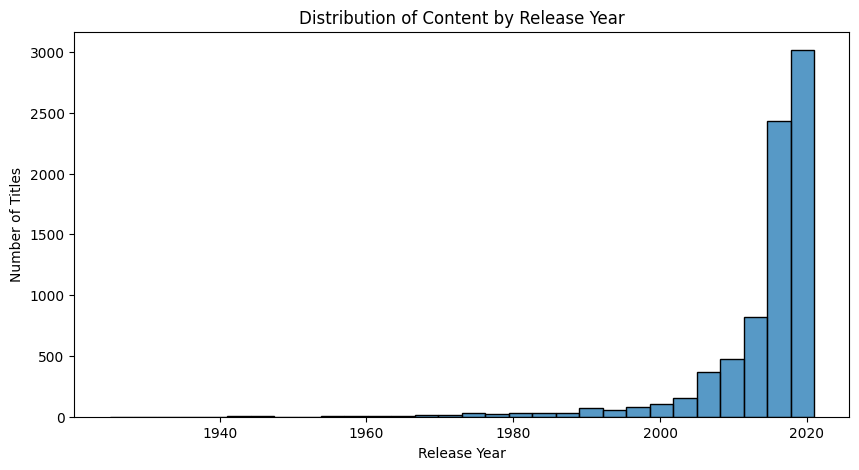

In [64]:
plt.figure(figsize=(10, 5))
sns.histplot(data=netflix, x='release_year', bins=30)
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.title("Distribution of Content by Release Year")
plt.show()

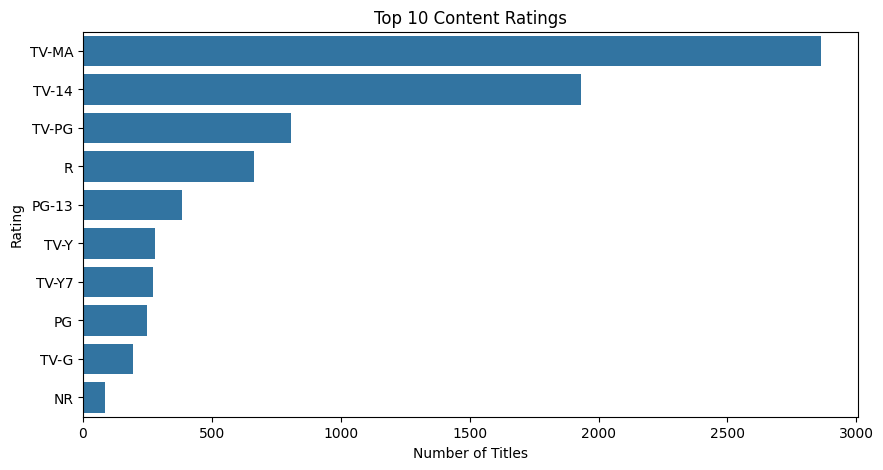

In [65]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=netflix,
    y='rating',
    order=netflix['rating'].value_counts().head(10).index
)
plt.xlabel("Number of Titles")
plt.ylabel("Rating")
plt.title("Top 10 Content Ratings")
plt.show()

In [66]:
netflix['date_added'] = pd.to_datetime(netflix['date_added'], errors='coerce')

netflix['added_year'] = netflix['date_added'].dt.year

print(netflix[['date_added', 'added_year']].head())

  date_added  added_year
0 2020-08-14      2020.0
1 2017-12-15      2017.0
2 2019-01-05      2019.0
3 2016-03-01      2016.0
4 2018-12-03      2018.0


/tmp/ipykernel_1530/2661242646.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  netflix['date_added'] = pd.to_datetime(netflix['date_added'], errors='coerce')


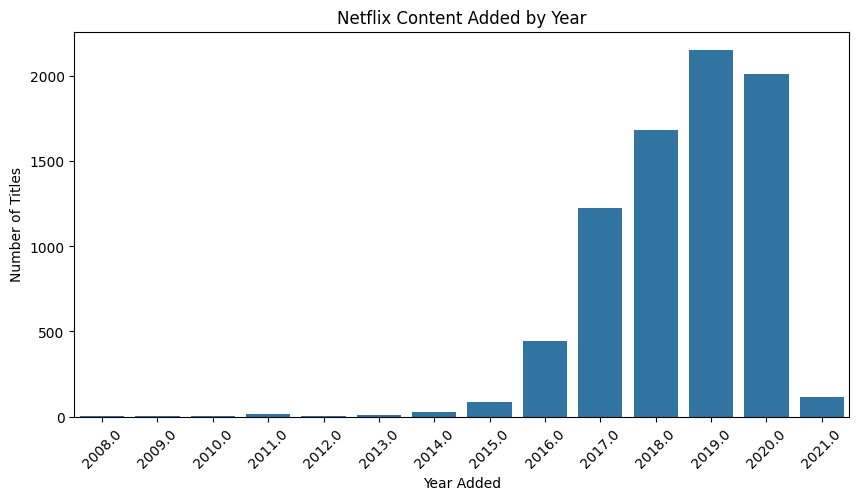

In [67]:
plt.figure(figsize=(10, 5))
sns.countplot(data=netflix, x='added_year')
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.title("Netflix Content Added by Year")
plt.xticks(rotation=45)
plt.show()

In [68]:
missing = netflix.isnull().sum().sort_values(ascending=False)

print("Missing Values:")
print(missing)

Missing Values:
director        2389
cast             718
country          507
date_added        10
added_year        10
rating             7
type               0
show_id            0
title              0
release_year       0
duration           0
genres             0
description        0
dtype: int64


In [69]:
print("Duplicate Rows:", netflix.duplicated().sum())

Duplicate Rows: 0


**Insights:**

- The dataset contains both movies and TV shows.
- Netflix content spans several release years.
- Different content ratings are present in the dataset.
- The number of titles added to Netflix varies across years.
- Some attributes such as director, cast and country contain missing values.
- The dataset contains both categorical and date-related information that can be explored through visualizations.

Question 7F - Student Dataset

In [69]:
student = pd.read_csv("student_data.csv")

print("Shape:", student.shape)
student.head()

Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [70]:
print("Columns:")
print(student.columns.tolist())

print("\nData Types:")
print(student.dtypes)

print("\nMissing Values:")
print(student.isnull().sum())

print("\nDuplicate Rows:")
print(student.duplicated().sum())

print("\nStatistical Summary:")
print(student.describe(include='all'))

Columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Data Types:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64

In [71]:
print("Missing Values:")
print(student.isnull().sum())

print("\nDuplicate Rows:")
print(student.duplicated().sum())

Missing Values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Duplicate Rows:
0


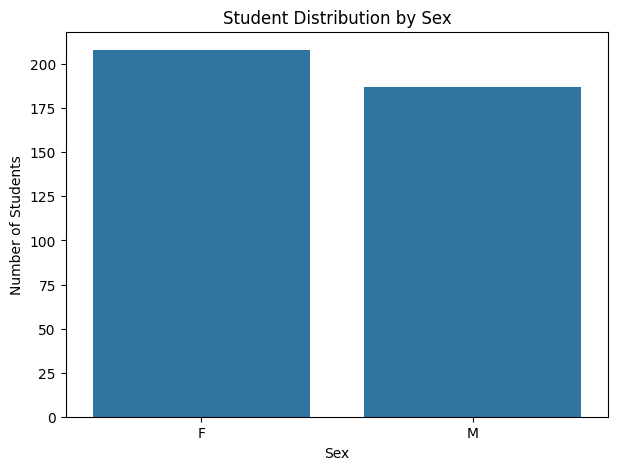

In [75]:
plt.figure(figsize=(7, 5))
sns.countplot(data=student, x='sex')
plt.xlabel("Sex")
plt.ylabel("Number of Students")
plt.title("Student Distribution by Sex")
plt.show()

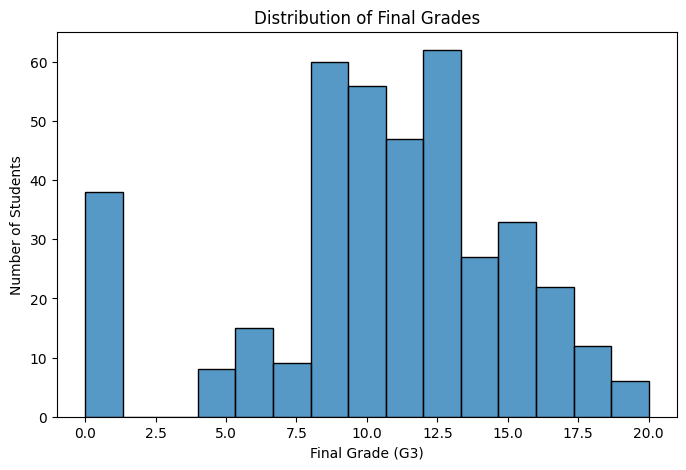

In [72]:
plt.figure(figsize=(8, 5))
sns.histplot(data=student, x='G3', bins=15)
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Grades")
plt.show()

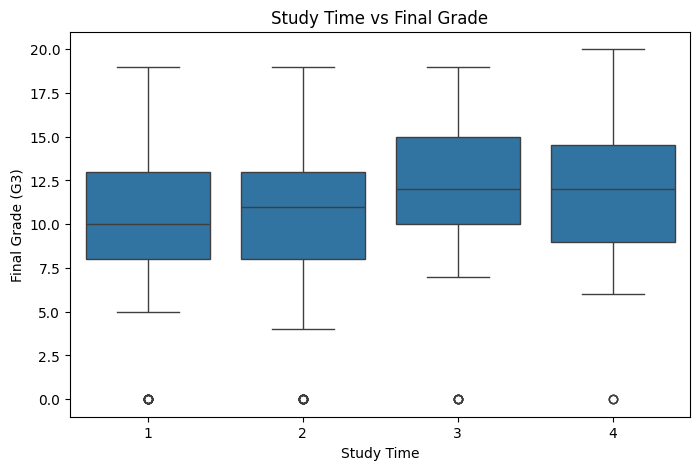

In [73]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=student, x='studytime', y='G3')
plt.xlabel("Study Time")
plt.ylabel("Final Grade (G3)")
plt.title("Study Time vs Final Grade")
plt.show()

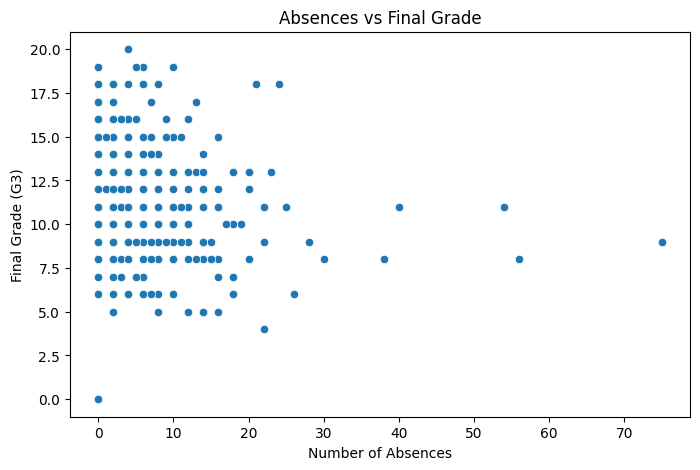

In [74]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=student, x='absences', y='G3')
plt.xlabel("Number of Absences")
plt.ylabel("Final Grade (G3)")
plt.title("Absences vs Final Grade")
plt.show()

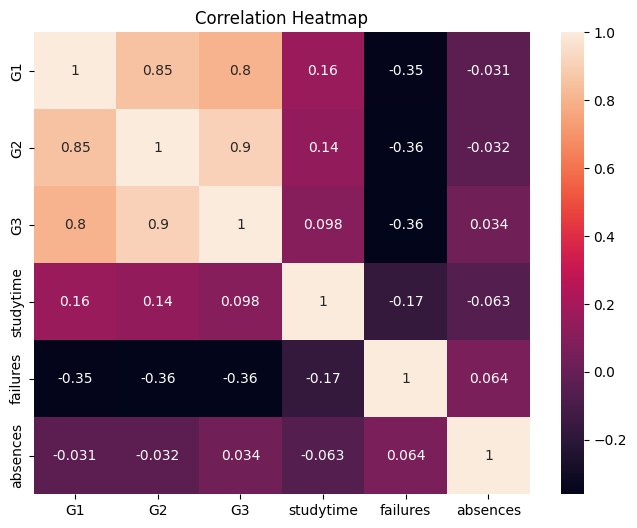

In [75]:
plt.figure(figsize=(8, 6))

corr = student[['G1', 'G2', 'G3', 'studytime', 'failures', 'absences']].corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")
plt.show()

**Insights:**

- The dataset contains information about students' academic performance and personal characteristics.
- The final grade (G3) varies considerably among students.
- Study time shows a relationship with students' final grades.
- Students with more previous failures generally tend to have lower final grades.
- Absences can have an effect on academic performance.
- G1 and G2 have a strong relationship with the final grade G3.

Question 7G - Superstore Dataset

In [76]:
superstore = pd.read_csv("Superstore.csv", encoding="latin1")

print("Shape:", superstore.shape)
superstore.head()

Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [77]:
print("Columns:")
print(superstore.columns.tolist())

print("\nData Types:")
print(superstore.dtypes)

print("\nMissing Values:")
print(superstore.isnull().sum())

print("\nDuplicate Rows:")
print(superstore.duplicated().sum())

print("\nStatistical Summary:")
print(superstore.describe(include='all'))

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country   

In [78]:
for col in superstore.columns:
    print(col)

Row ID
Order ID
Order Date
Ship Date
Ship Mode
Customer ID
Customer Name
Segment
Country
City
State
Postal Code
Region
Product ID
Category
Sub-Category
Product Name
Sales
Quantity
Discount
Profit


In [79]:
print("Shape:", superstore.shape)

print("\nColumns:")
print(superstore.columns.tolist())

print("\nData Types:")
print(superstore.dtypes)

print("\nMissing Values:")
print(superstore.isnull().sum())

print("\nDuplicate Rows:", superstore.duplicated().sum())

Shape: (9994, 21)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment   

In [80]:
superstore.describe(include='all')

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994,9994,9994,9994,9994,9994,9994,...,9994.000000,9994,9994,9994,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
unique,NaN,5009,1238,1334,4,793,793,3,1,531,...,NaN,4,1862,3,17,1841,NaN,NaN,NaN,NaN
top,NaN,CA-2014-100111,06-09-2013,16-12-2012,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,...,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staples,NaN,NaN,NaN,NaN
freq,NaN,14,38,35,5968,37,37,5191,9994,915,...,NaN,3203,19,6026,1523,227,NaN,NaN,NaN,NaN
mean,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,55190.379428,NaN,NaN,NaN,NaN,NaN,229.858001,3.789574,0.156203,28.656896
std,2885.163629,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,32063.693350,NaN,NaN,NaN,NaN,NaN,623.245101,2.225110,0.206452,234.260108
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23223.000000,NaN,NaN,NaN,NaN,NaN,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,56430.500000,NaN,NaN,NaN,NaN,NaN,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,90008.000000,NaN,NaN,NaN,NaN,NaN,209.940000,5.000000,0.200000,29.364000


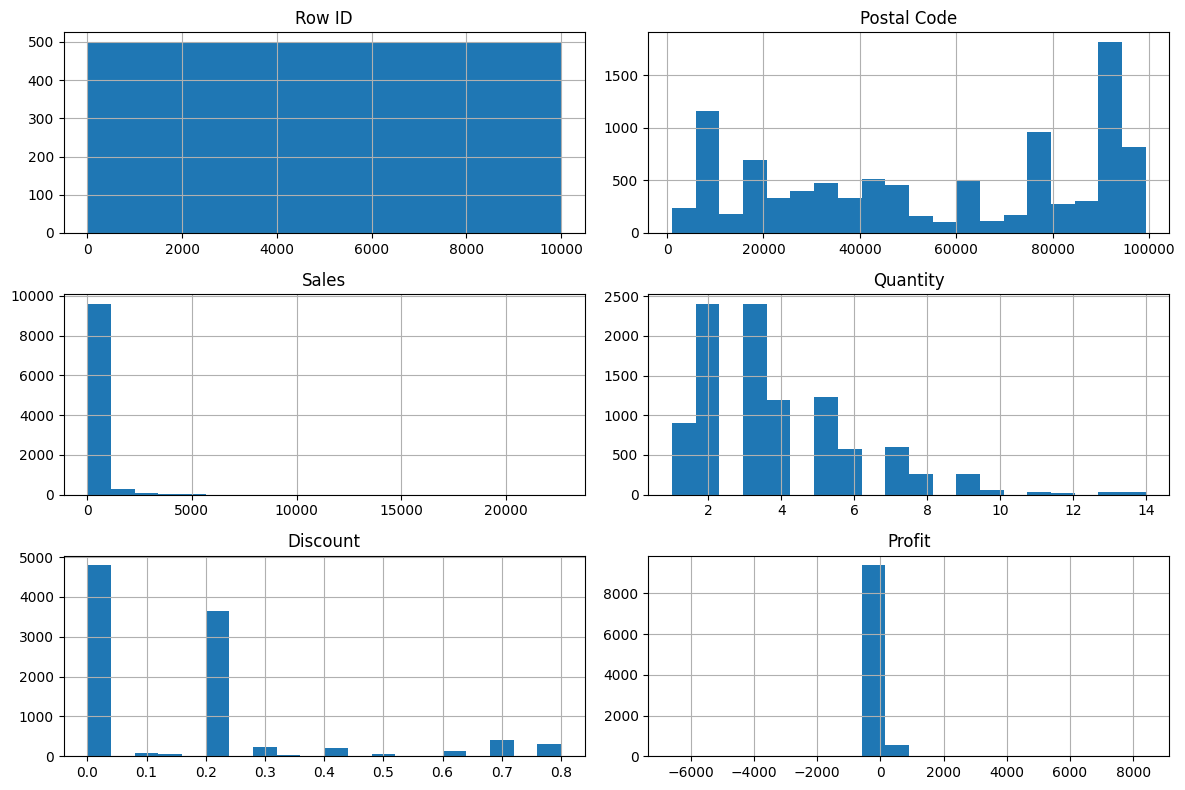

In [81]:
superstore.hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

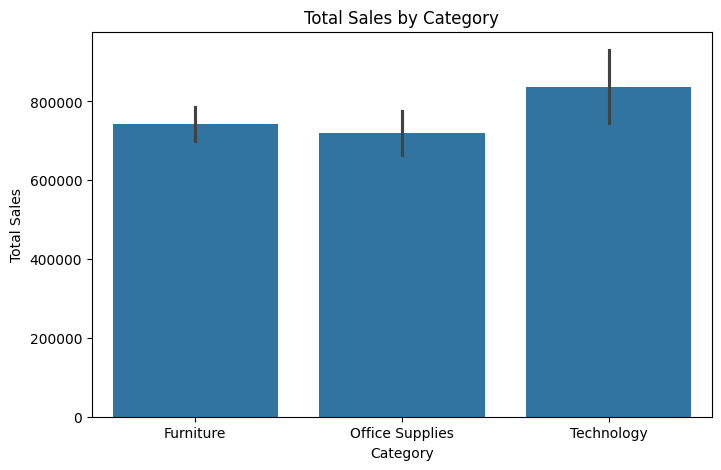

In [82]:
plt.figure(figsize=(8,5))

sns.barplot(data=superstore, x="Category", y="Sales", estimator="sum")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

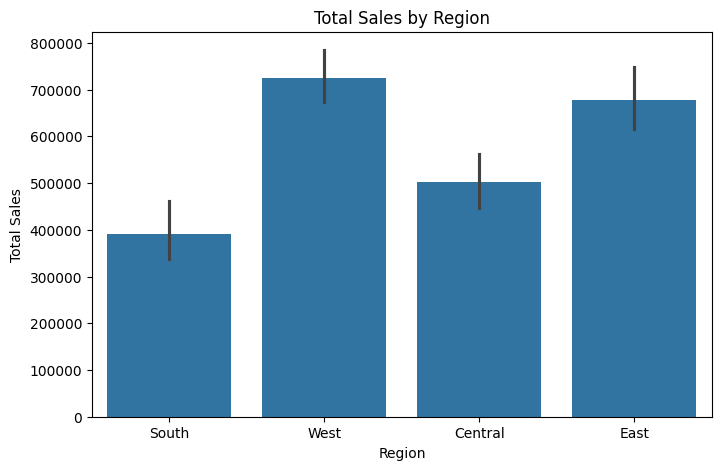

In [83]:
plt.figure(figsize=(8,5))

sns.barplot(data=superstore, x="Region", y="Sales", estimator="sum")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

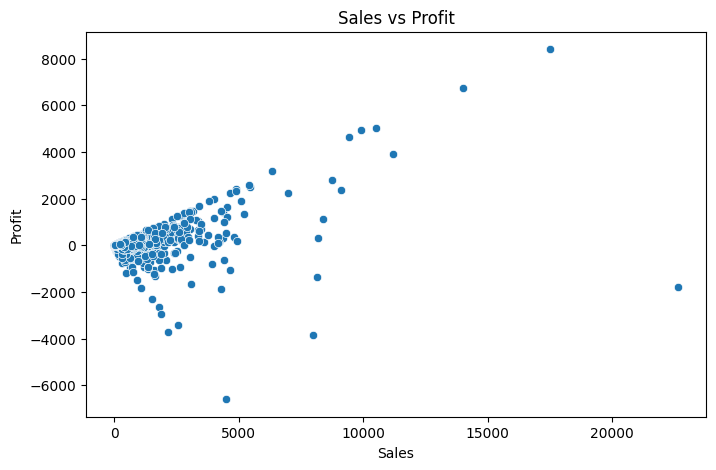

In [84]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=superstore, x="Sales", y="Profit")

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

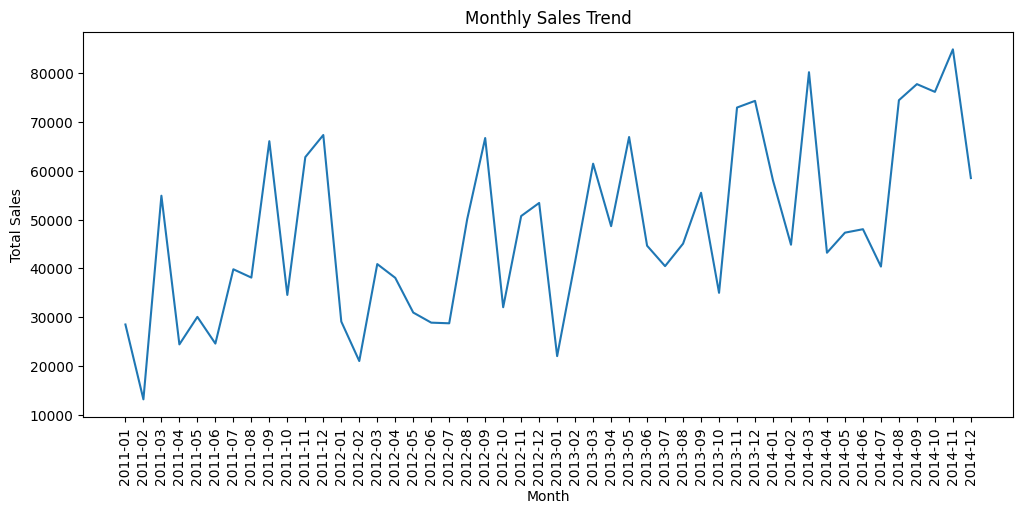

In [85]:
superstore["Order Date"] = pd.to_datetime(
    superstore["Order Date"],
    format="mixed"
)

monthly_sales = superstore.groupby(
    superstore["Order Date"].dt.to_period("M")
)["Sales"].sum()

plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)

plt.show()

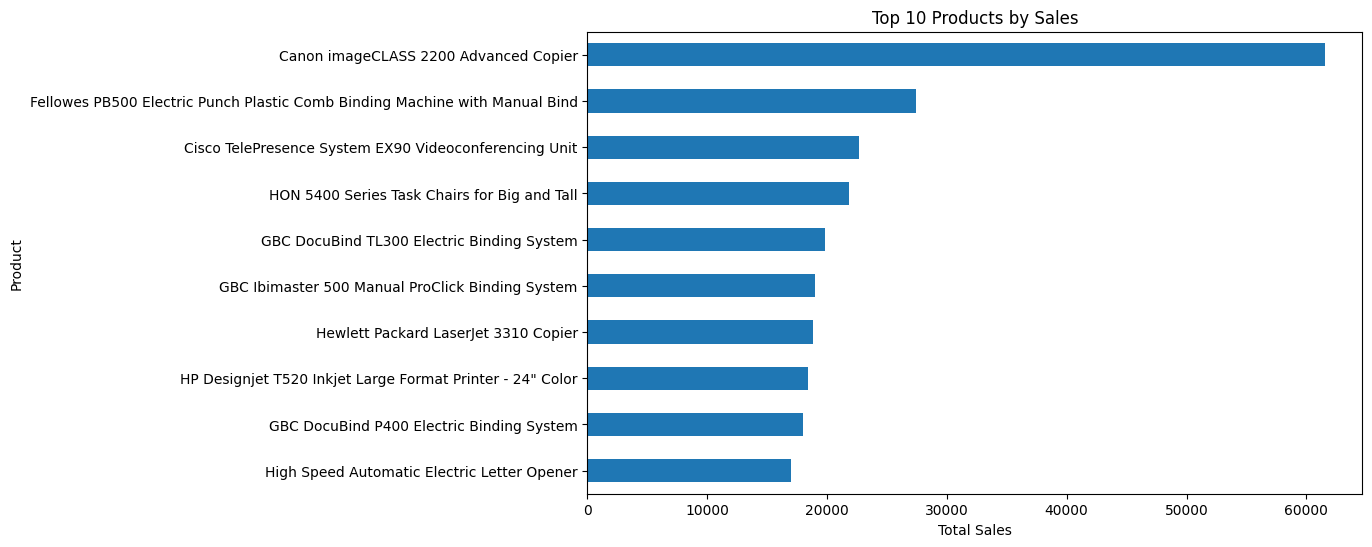

In [86]:
top_products = (
    superstore.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.show()

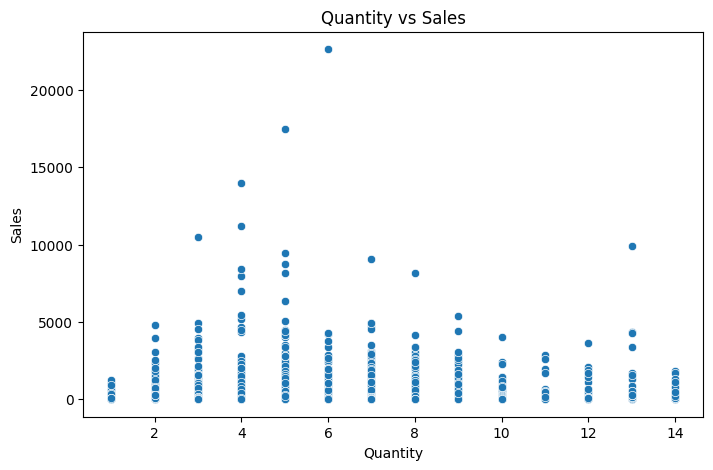

In [87]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=superstore,
    x="Quantity",
    y="Sales"
)

plt.title("Quantity vs Sales")
plt.xlabel("Quantity")
plt.ylabel("Sales")

plt.show()

In [88]:
print("Missing Values:")
print(superstore.isnull().sum())

superstore = superstore.drop_duplicates()

print("\nShape after cleaning:", superstore.shape)

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Shape after cleaning: (9994, 21)


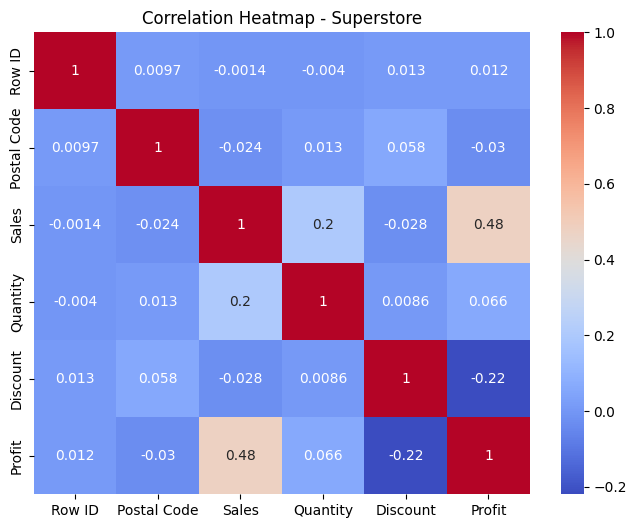

In [89]:
plt.figure(figsize=(8,6))

sns.heatmap(
    superstore.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap - Superstore")
plt.show()

Insights from Superstore Dataset:

1. The dataset contains information about orders, products, customers, sales and profit.

2. The category-wise analysis shows that some product categories contribute significantly more to total sales than others.

3. Sales vary across different regions, indicating differences in regional performance.

4. The Sales vs Profit scatter plot shows that higher sales do not always guarantee proportionally higher profit.

5. The monthly sales trend shows variations in sales over time, with certain months performing better than others.

6. The top 10 product analysis identifies the products contributing the most to overall sales.

7. The Quantity vs Sales plot indicates a positive relationship between quantity sold and sales in general.

8. The correlation analysis helps identify relationships between numerical variables such as Sales, Quantity, Discount and Profit.

Question 7H - Car Price Dataset Load

In [90]:
car = pd.read_csv("CarPrice_Assignment.csv")

print("Shape:", car.shape)
car.head()

Shape: (205, 26)


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [91]:
print("Columns:")
print(car.columns.tolist())

print("\nData Types:")
print(car.dtypes)

print("\nMissing Values:")
print(car.isnull().sum())

print("\nDuplicate Rows:", car.duplicated().sum())

Columns:
['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']

Data Types:
car_ID                int64
symboling             int64
CarName              object
fueltype             object
aspiration           object
doornumber           object
carbody              object
drivewheel           object
enginelocation       object
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype           object
cylindernumber       object
enginesize            int64
fuelsystem           object
boreratio           float64
stroke              float64
compressionratio    float64
horsepower            int64
peakrpm          

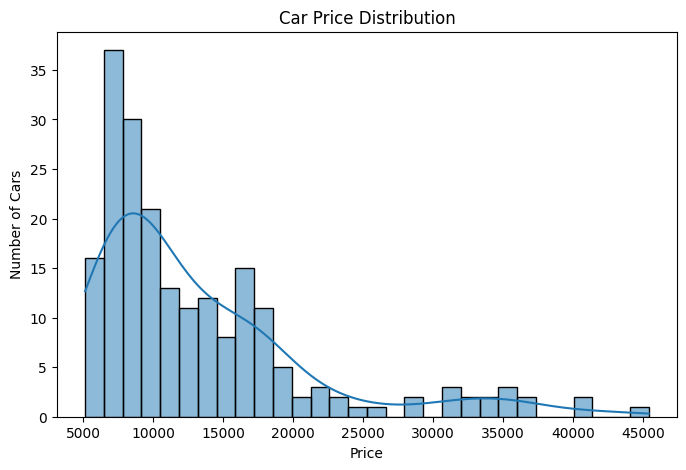

In [92]:
plt.figure(figsize=(8,5))

sns.histplot(data=car, x="price", bins=30, kde=True)

plt.title("Car Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Cars")

plt.show()

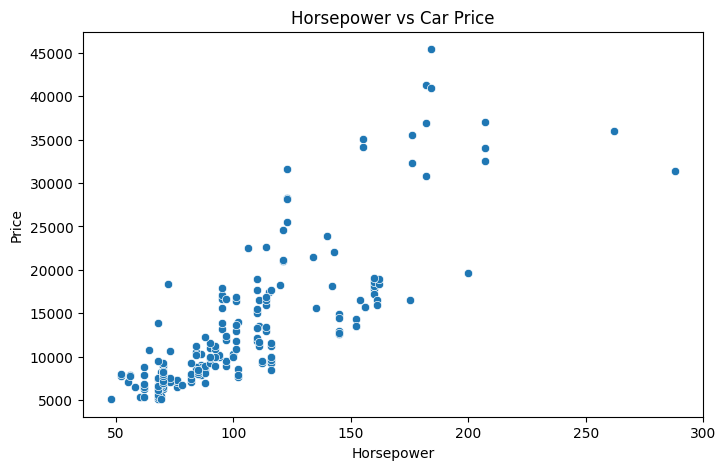

In [93]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=car, x="horsepower", y="price")

plt.title("Horsepower vs Car Price")
plt.xlabel("Horsepower")
plt.ylabel("Price")

plt.show()

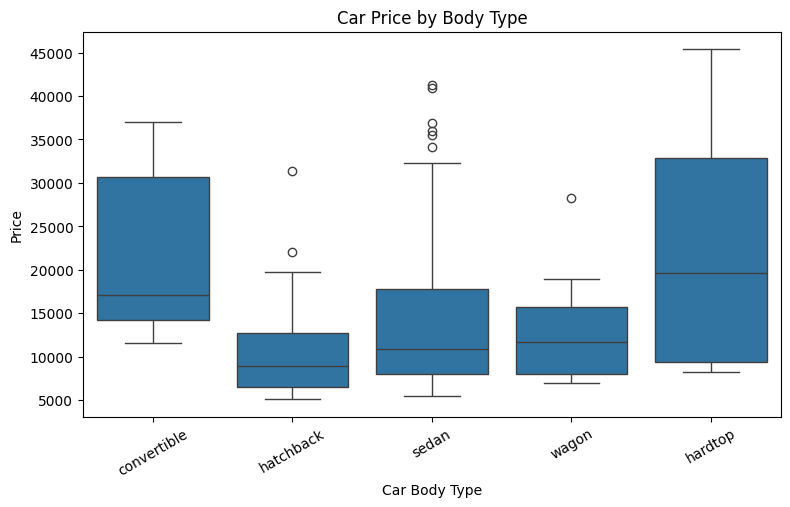

In [94]:
plt.figure(figsize=(9,5))

sns.boxplot(data=car, x="carbody", y="price")

plt.title("Car Price by Body Type")
plt.xlabel("Car Body Type")
plt.ylabel("Price")

plt.xticks(rotation=30)

plt.show()

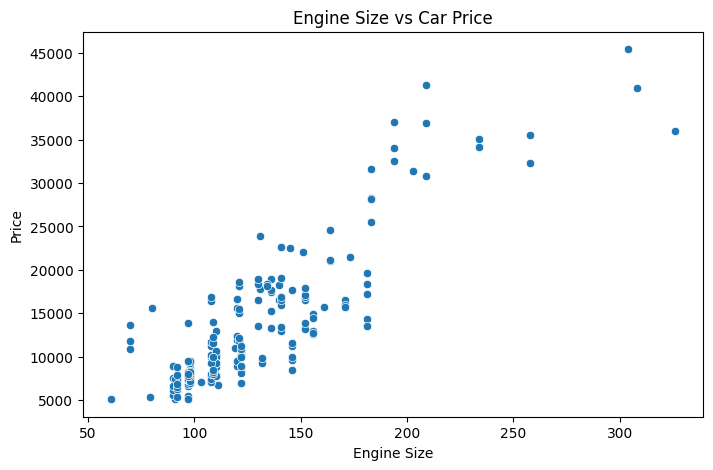

In [95]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=car, x="enginesize", y="price")

plt.title("Engine Size vs Car Price")
plt.xlabel("Engine Size")
plt.ylabel("Price")

plt.show()

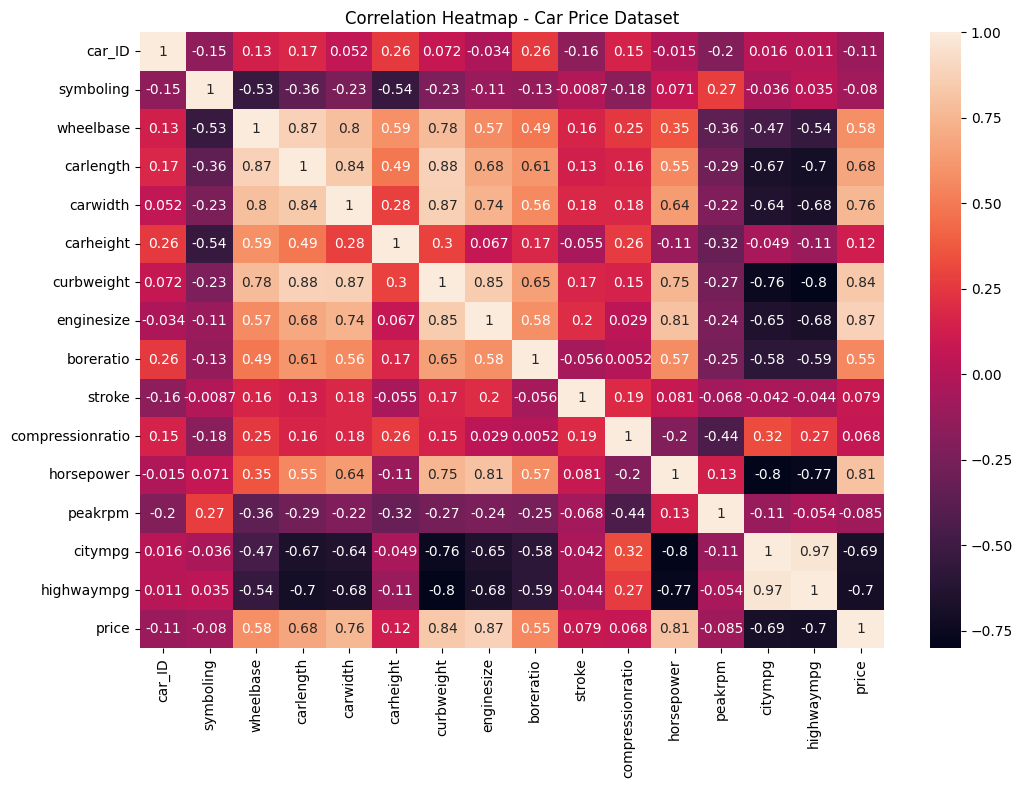

In [96]:
plt.figure(figsize=(12,8))

corr = car.select_dtypes(include="number").corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap - Car Price Dataset")
plt.show()

In [97]:
print("Missing Values:")
print(car.isnull().sum())

print("\nDuplicate Rows:", car.duplicated().sum())

Missing Values:
car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

Duplicate Rows: 0


Insights from Car Price Dataset:

1. Car prices show considerable variation across different vehicles.

2. The price distribution shows that most cars are concentrated within a particular price range, while some cars have relatively high prices.

3. Horsepower and engine size show a positive relationship with car price in general.

4. Car prices vary across different body types.

5. The correlation heatmap shows relationships between price and other numerical features.

6. The dataset does not contain significant missing values, making it suitable for further analysis.

Question 7I - Train and Test Dataset

In [100]:
train_test = pd.read_csv("train_and_test2.csv")

print("Shape:", train_test.shape)
train_test.head()

Shape: (1309, 28)


,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [101]:
print("Columns:")
print(train_test.columns.tolist())

print("\nData Types:")
print(train_test.dtypes)

print("\nMissing Values:")
print(train_test.isnull().sum())

print("\nDuplicate Rows:")
print(train_test.duplicated().sum())

print("\nStatistical Summary:")
print(train_test.describe(include='all'))

Columns:
['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13', 'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17', 'zero.18', '2urvived']

Data Types:
Passengerid      int64
Age            float64
Fare           float64
Sex              int64
sibsp            int64
zero             int64
zero.1           int64
zero.2           int64
zero.3           int64
zero.4           int64
zero.5           int64
zero.6           int64
Parch            int64
zero.7           int64
zero.8           int64
zero.9           int64
zero.10          int64
zero.11          int64
zero.12          int64
zero.13          int64
zero.14          int64
Pclass           int64
zero.15          int64
zero.16          int64
Embarked       float64
zero.17          int64
zero.18          int64
2urvived         int64
dtype: object

Missing Values:
Passengerid    0

In [102]:
for col in train_test.columns:
    print(col)

Passengerid
Age
Fare
Sex
sibsp
zero
zero.1
zero.2
zero.3
zero.4
zero.5
zero.6
Parch
zero.7
zero.8
zero.9
zero.10
zero.11
zero.12
zero.13
zero.14
Pclass
zero.15
zero.16
Embarked
zero.17
zero.18
2urvived


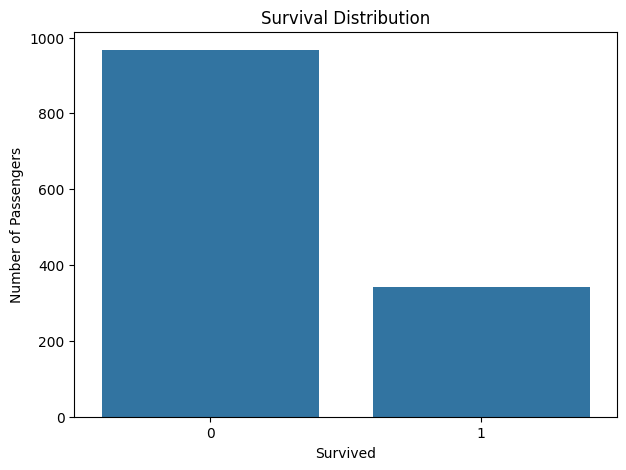

In [103]:
plt.figure(figsize=(7,5))

sns.countplot(data=train_test, x='2urvived')

plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")

plt.show()

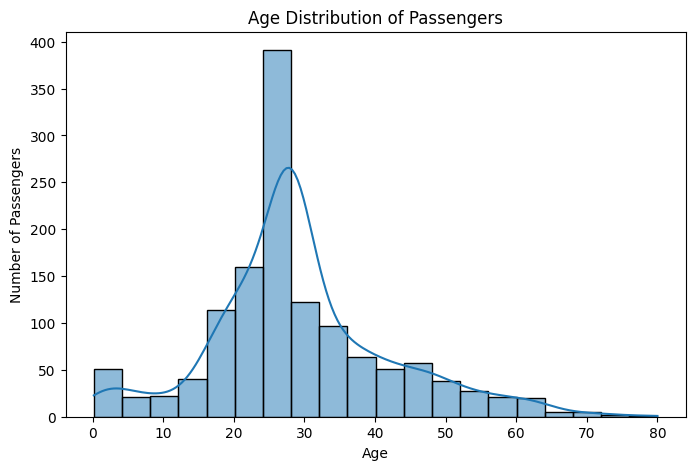

In [104]:
plt.figure(figsize=(8,5))

sns.histplot(data=train_test, x='Age', bins=20, kde=True)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

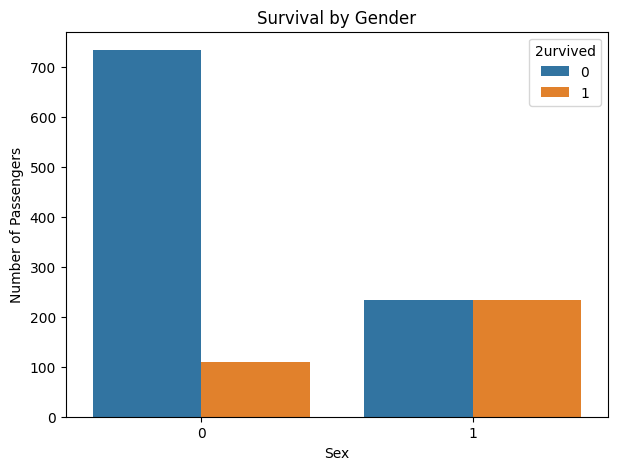

In [105]:
plt.figure(figsize=(7,5))

sns.countplot(data=train_test, x='Sex', hue='2urvived')

plt.title("Survival by Gender")
plt.xlabel("Sex")
plt.ylabel("Number of Passengers")

plt.show()

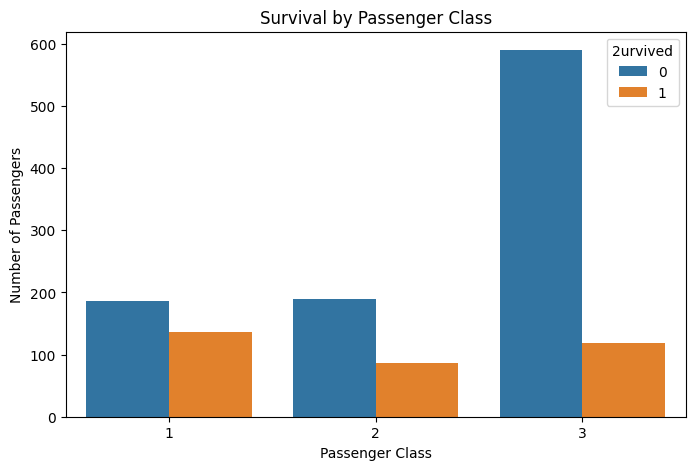

In [106]:
plt.figure(figsize=(8,5))

sns.countplot(data=train_test, x='Pclass', hue='2urvived')

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

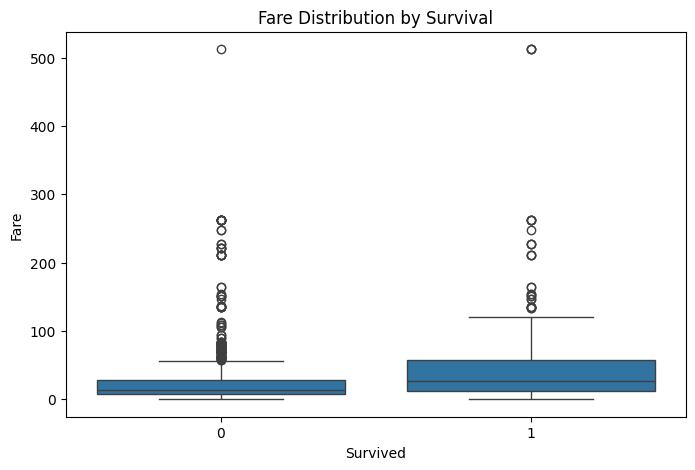

In [107]:
plt.figure(figsize=(8,5))

sns.boxplot(data=train_test, x='2urvived', y='Fare')

plt.title("Fare Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Fare")

plt.show()

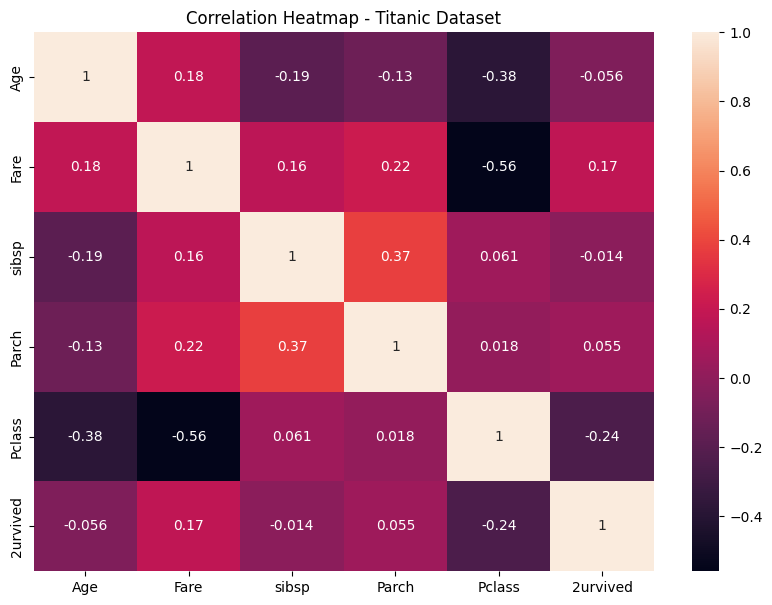

In [108]:
plt.figure(figsize=(10,7))

corr = train_test[['Age', 'Fare', 'sibsp', 'Parch', 'Pclass', '2urvived']].corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap - Titanic Dataset")
plt.show()

Insights from Train and Test Dataset:

1. The dataset contains passenger information including age, gender, fare and passenger class.

2. The survival distribution shows the number of passengers who survived and did not survive.

3. Survival rates differ between male and female passengers.

4. Passenger class has a noticeable relationship with survival.

5. Fare values vary between passengers with different survival outcomes.

6. The correlation heatmap shows relationships between numerical passenger attributes and survival.

Question 7J - Weather Dataset

In [109]:
weather = pd.read_csv("weather.csv")

print("Shape:", weather.shape)
weather.head()

Shape: (22, 34)


,year,month,element,day1,day2,day3,day4,day5,day6,day7,...,day22,day23,day24,day25,day26,day27,day28,day29,day30,day31
0,2018,1,max,17.573016,19.796815,22.412495,17.813163,20.165825,17.060539,22.736134,...,22.629226,19.013674,17.831558,17.018316,21.837387,19.700255,19.084056,18.534690,20.787275,21.117423
1,2018,1,min,22.725760,21.007865,17.730792,18.045290,20.766734,18.656651,22.607481,...,21.163491,17.371653,17.194530,18.964190,17.892385,17.646139,19.844125,22.729859,19.768917,20.913443
2,2018,2,max,19.015120,19.261805,17.510713,21.080425,17.915749,19.082145,18.056023,...,21.254968,20.346324,20.036019,22.926773,17.533172,20.308927,20.438899,17.005806,18.346534,20.878165
3,2018,2,min,18.653843,22.818600,21.842673,21.958159,22.523078,18.535469,19.636158,...,19.711974,20.586232,18.780840,20.065633,18.293548,20.823661,18.056112,22.748292,22.470172,18.602007
4,2018,3,max,20.741115,19.704016,17.039811,20.703908,22.714125,17.205000,19.079503,...,19.528963,19.563689,22.658997,22.446357,17.911240,22.591993,17.406800,19.118712,22.767154,17.119452


In [110]:
print("Columns:")
print(weather.columns.tolist())

print("\nData Types:")
print(weather.dtypes)

print("\nMissing Values:")
print(weather.isnull().sum())

print("\nDuplicate Rows:")
print(weather.duplicated().sum())

print("\nStatistical Summary:")
print(weather.describe(include='all'))

Columns:
['year', 'month', 'element', 'day1', 'day2', 'day3', 'day4', 'day5', 'day6', 'day7', 'day8', 'day9', 'day10', 'day11', 'day12', 'day13', 'day14', 'day15', 'day16', 'day17', 'day18', 'day19', 'day20', 'day21', 'day22', 'day23', 'day24', 'day25', 'day26', 'day27', 'day28', 'day29', 'day30', 'day31']

Data Types:
year         int64
month        int64
element     object
day1       float64
day2       float64
day3       float64
day4       float64
day5       float64
day6       float64
day7       float64
day8       float64
day9       float64
day10      float64
day11      float64
day12      float64
day13      float64
day14      float64
day15      float64
day16      float64
day17      float64
day18      float64
day19      float64
day20      float64
day21      float64
day22      float64
day23      float64
day24      float64
day25      float64
day26      float64
day27      float64
day28      float64
day29      float64
day30      float64
day31      float64
dtype: object

Missing Values:
ye

In [111]:
for col in weather.columns:
    print(col)

year
month
element
day1
day2
day3
day4
day5
day6
day7
day8
day9
day10
day11
day12
day13
day14
day15
day16
day17
day18
day19
day20
day21
day22
day23
day24
day25
day26
day27
day28
day29
day30
day31


In [112]:
print("Number of rows:", len(weather))
print("Number of columns:", len(weather.columns))

print("\nWeather Elements:")
print(weather['element'].unique())

print("\nMissing Values:")
print(weather.isnull().sum().sum())

Number of rows: 22
Number of columns: 34

Weather Elements:
['max' 'min']

Missing Values:
0


In [113]:
day_columns = [f'day{i}' for i in range(1, 32)]

weather_long = weather.melt(
    id_vars=['year', 'month', 'element'],
    value_vars=day_columns,
    var_name='Day',
    value_name='Value'
)

weather_long['Day'] = weather_long['Day'].str.replace('day', '').astype(int)

weather_long.head()

,year,month,element,Day,Value
0,2018,1,max,1,17.573016
1,2018,1,min,1,22.725760
2,2018,2,max,1,19.015120
3,2018,2,min,1,18.653843
4,2018,3,max,1,20.741115


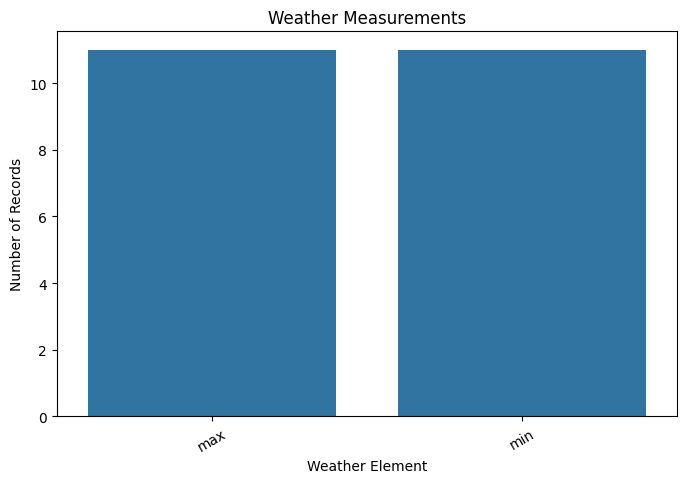

In [114]:
plt.figure(figsize=(8,5))

sns.countplot(data=weather, x='element')

plt.title("Weather Measurements")
plt.xlabel("Weather Element")
plt.ylabel("Number of Records")

plt.xticks(rotation=30)
plt.show()

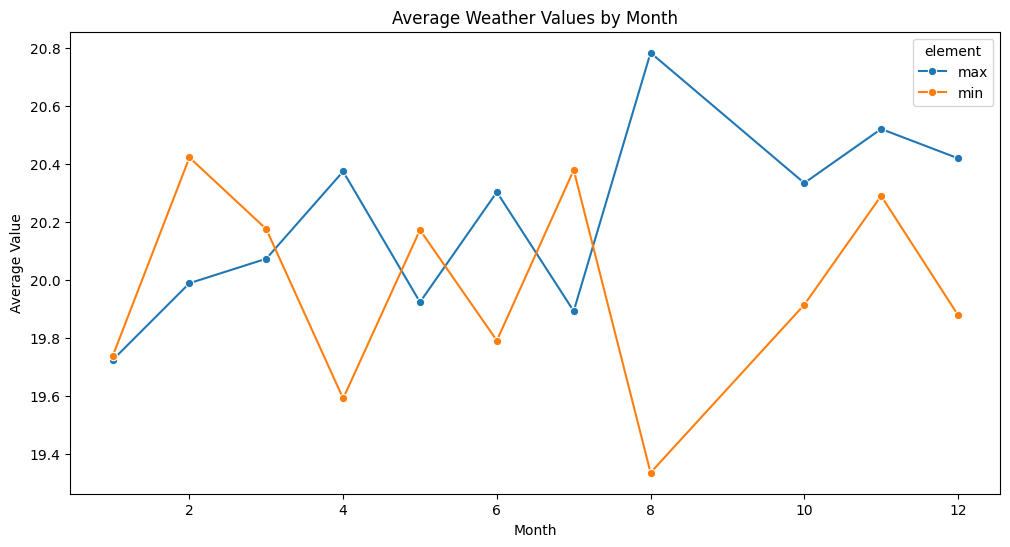

In [115]:
monthly_avg = (
    weather_long
    .groupby(['month', 'element'])['Value']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_avg,
    x='month',
    y='Value',
    hue='element',
    marker='o'
)

plt.title("Average Weather Values by Month")
plt.xlabel("Month")
plt.ylabel("Average Value")

plt.show()

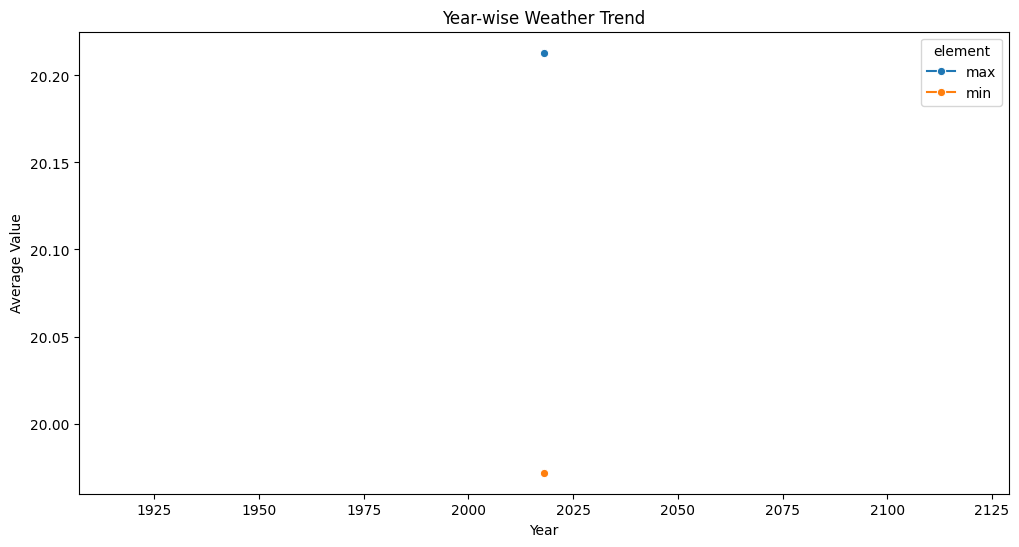

In [116]:
yearly_avg = (
    weather_long
    .groupby(['year', 'element'])['Value']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=yearly_avg,
    x='year',
    y='Value',
    hue='element',
    marker='o'
)

plt.title("Year-wise Weather Trend")
plt.xlabel("Year")
plt.ylabel("Average Value")

plt.show()

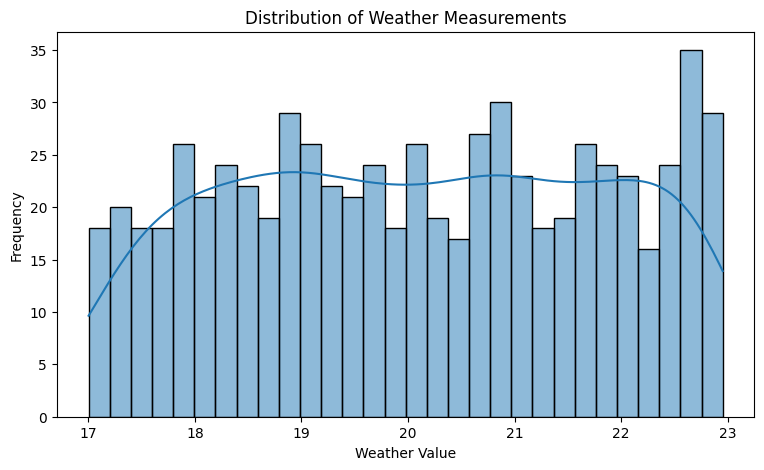

In [117]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=weather_long,
    x='Value',
    bins=30,
    kde=True
)

plt.title("Distribution of Weather Measurements")
plt.xlabel("Weather Value")
plt.ylabel("Frequency")

plt.show()

Insights from Weather Dataset:

1. The dataset contains weather measurements recorded across different years and months.

2. The data contains multiple weather elements measured for individual days.

3. Reshaping the daily columns makes it easier to analyze monthly and yearly weather trends.

4. The monthly analysis shows variation in weather measurements across different months.

5. The yearly trend helps identify changes in weather measurements over time.

6. The distribution plot shows the overall variation in the recorded weather values.

Question 7J

In [118]:
wine = pd.read_csv("winequalityN.csv")

print("Shape:", wine.shape)
wine.head()

Shape: (6497, 13)


,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [120]:
print("Columns:")
print(wine.columns.tolist())

print("\nData Types:")
print(wine.dtypes)

print("\nMissing Values:")
print(wine.isnull().sum())

print("\nDuplicate Rows:")
print(wine.duplicated().sum())

print("\nStatistical Summary:")
print(wine.describe(include='all'))

SyntaxError: invalid syntax (209065951.py, line 14)

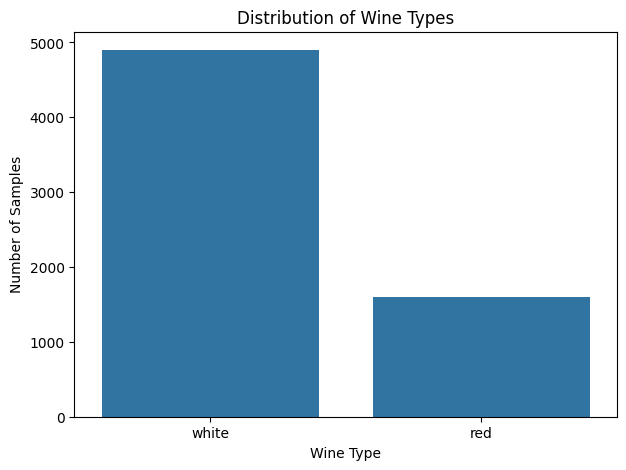

In [121]:
plt.figure(figsize=(7,5))

sns.countplot(data=wine, x='type')

plt.title("Distribution of Wine Types")
plt.xlabel("Wine Type")
plt.ylabel("Number of Samples")

plt.show()

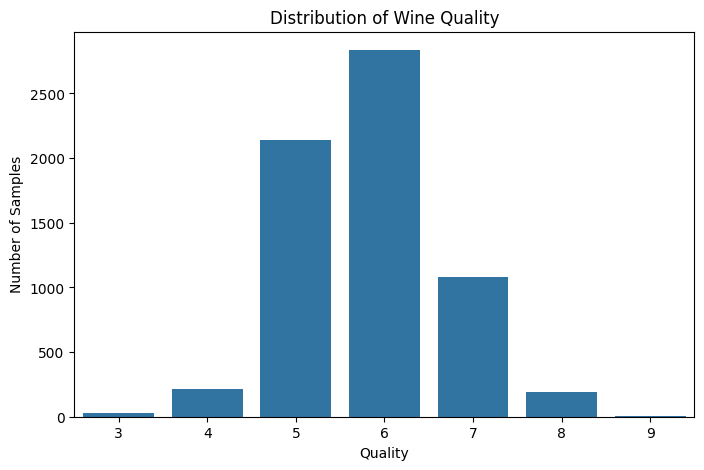

In [122]:
plt.figure(figsize=(8,5))

sns.countplot(data=wine, x='quality')

plt.title("Distribution of Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Number of Samples")

plt.show()

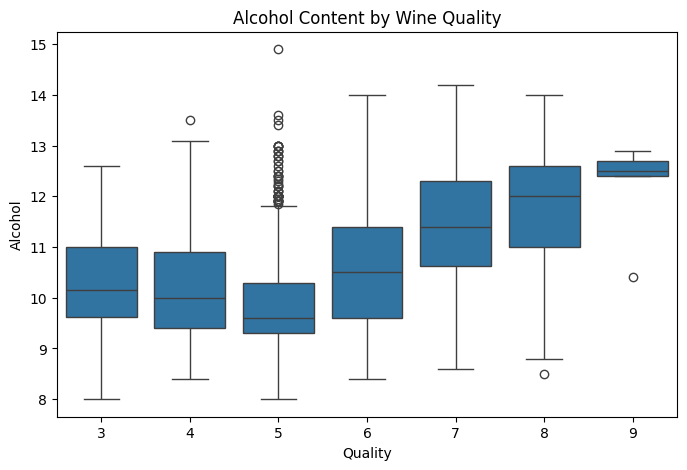

In [123]:
plt.figure(figsize=(8,5))

sns.boxplot(data=wine, x='quality', y='alcohol')

plt.title("Alcohol Content by Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Alcohol")

plt.show()

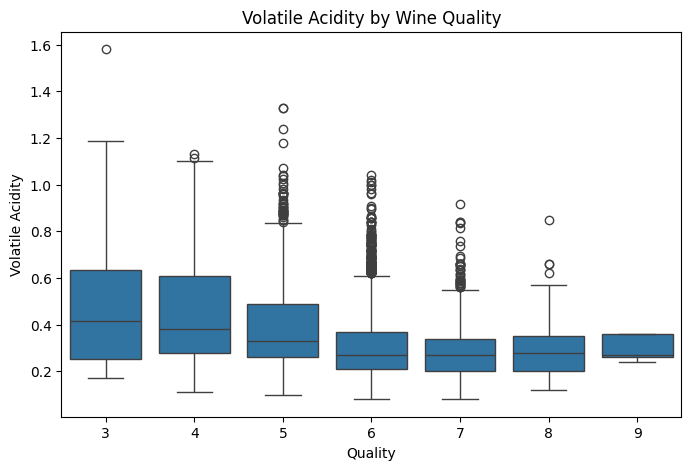

In [124]:
plt.figure(figsize=(8,5))

sns.boxplot(data=wine, x='quality', y='volatile acidity')

plt.title("Volatile Acidity by Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Volatile Acidity")

plt.show()

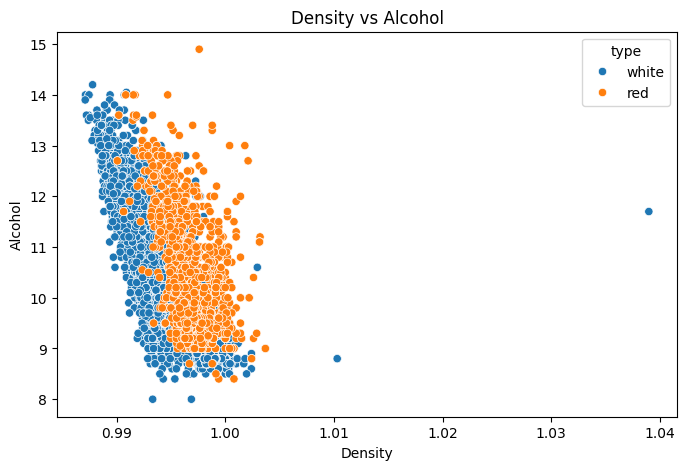

In [125]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=wine, x='density', y='alcohol', hue='type')

plt.title("Density vs Alcohol")
plt.xlabel("Density")
plt.ylabel("Alcohol")

plt.show()

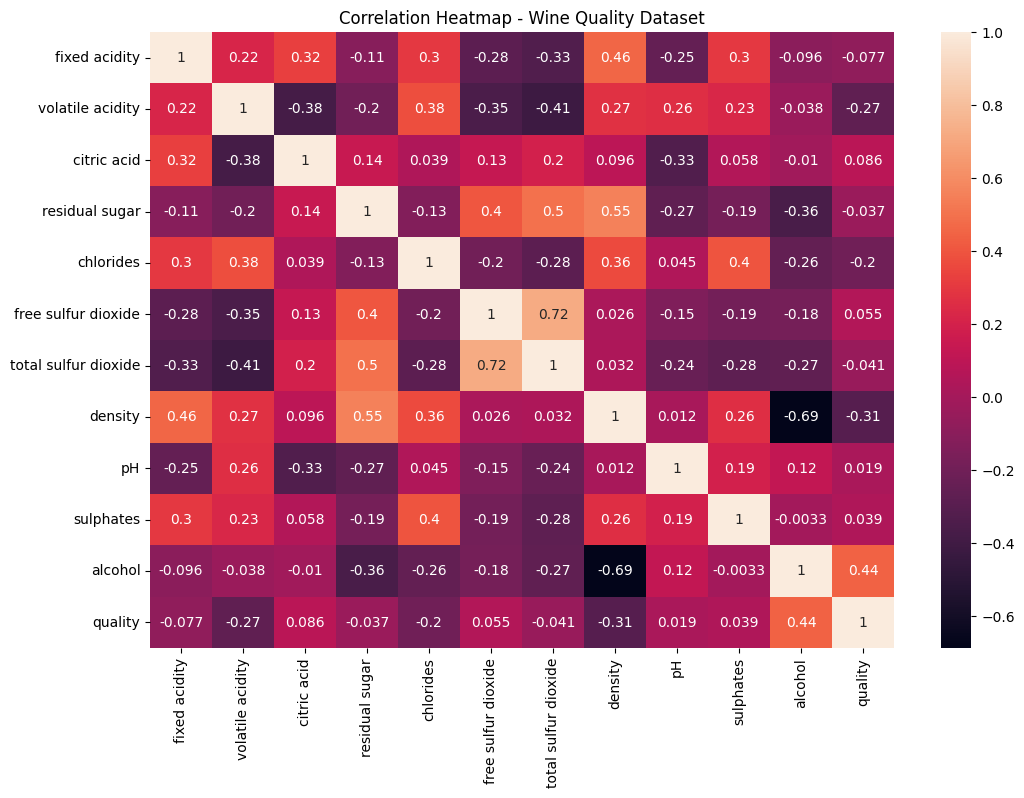

In [126]:
plt.figure(figsize=(12,8))

corr = wine.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap - Wine Quality Dataset")
plt.show()

Insights from Wine Quality Dataset:

1. The dataset contains both red and white wine samples with different chemical properties.

2. Wine quality scores vary across the dataset, with some quality levels occurring more frequently than others.

3. Alcohol content shows differences across different wine quality levels.

4. Volatile acidity also varies across wines with different quality scores.

5. Density and alcohol show a relationship that can be observed from the scatter plot.

6. The correlation heatmap helps identify relationships between different chemical properties and wine quality.